# Analysis code DF
<b> Analysis code for the research on dengue fever in Ningbo City

The analysis code provided with this manuscript was developed and executed on a de-identified research dataset. All records underwent standardised cleaning and pseudonymisation prior to analysis: direct identifiers (name, national ID number, contact details, and residential address) were removed, and no variable permitting re-identification of individual patients is retained. The code, together with the aggregated and derived data outputs it generates, is sufficient to reproduce all results, tables, and figures reported in this study.

Individual-level line-listing data cannot be released. Under the Infectious Disease Prevention and Control Law of the People's Republic of China, information relating to notified cases of infectious disease is subject to statutory confidentiality protection, and disclosure of identifiable case records to third parties is prohibited. Access to detailed individual-level data therefore requires formal application to, and approval by, the Ethics Committee of the Centers for Disease Control and Prevention, together with execution of a data use agreement specifying the permitted scope of use, storage, and destruction. Requests should be addressed to the corresponding author, who will coordinate the institutional review process; approval is not guaranteed and is assessed on a case-by-case basis.

## 1. Epidemiological characteristics of dengue fever case surveillance

### Table 2

### Figure 3

#### Fig 3A

检测到全0行: ['Phase II']，将排除


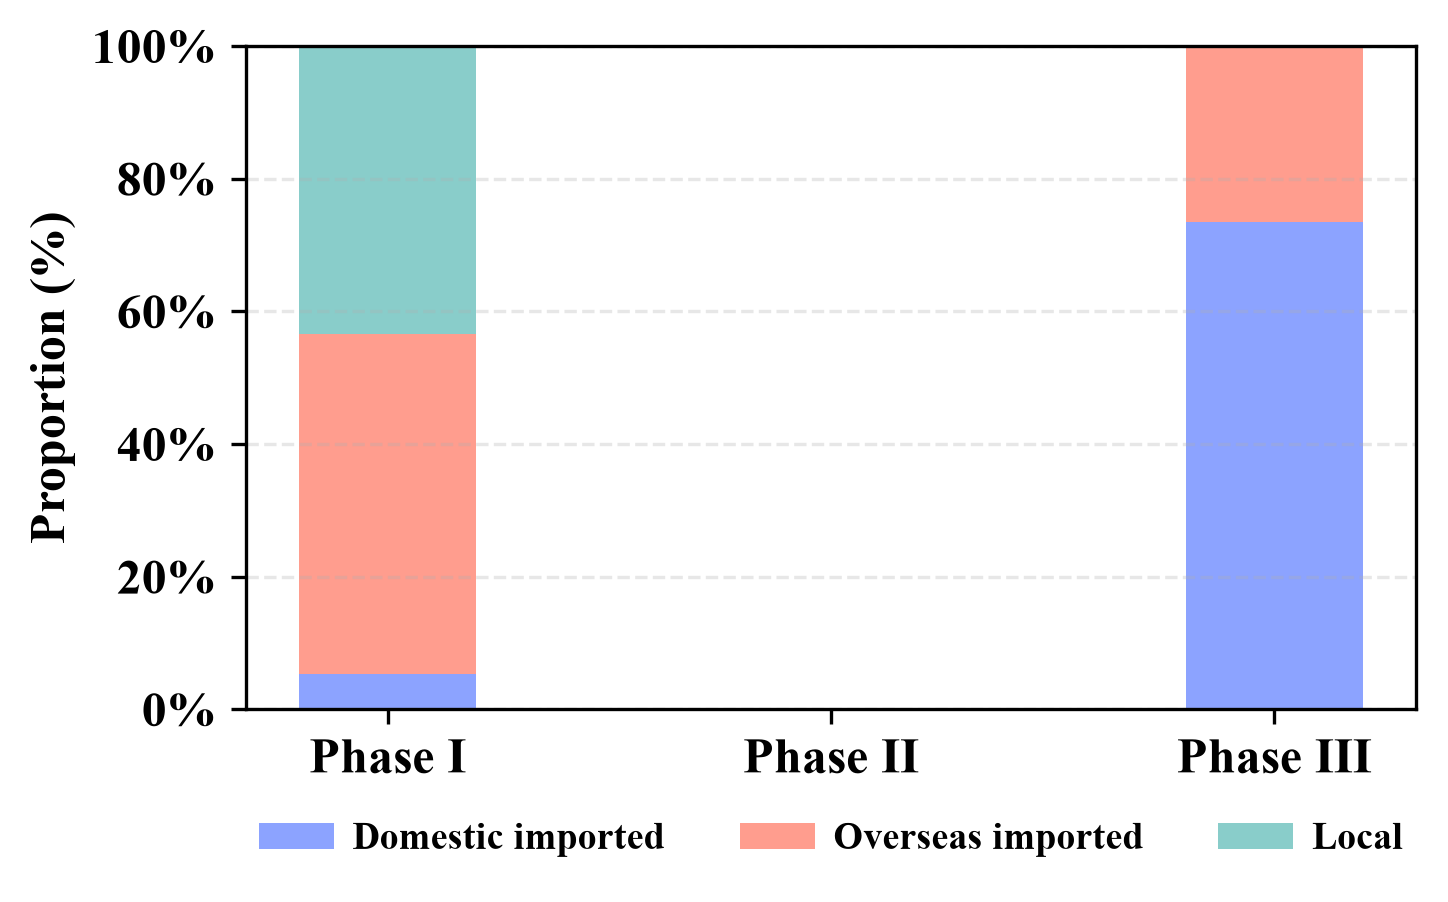

卡方检验结果: χ²(2)=145.82, p<0.001***
观察频数表:
[[ 9 86 73]
 [72 26  0]]

期望频数:
[[51.15789474 70.73684211 46.10526316]
 [29.84210526 41.26315789 26.89473684]]

样本量: 266
p值: 0.0000


In [28]:
# ==================== Fig3A ====================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 设置绘图样式
plt.rc('font', family='Times New Roman')
plt.rcParams.update({'font.size': 12})
plt.rcParams['font.weight'] = 'bold'
# 从Excel导入数据
data =  pd.read_excel('de-identified data.xlsx', sheet_name='Fig3A')

# 提取绘图数据
x = data['Phase'].values
y1 = data['Domestic_imported_proportion'].values
y2 = data['Overseas_imported_proportion'].values
y3 = data['Local_cases_proportion'].values

# 从原始计数重建观察频数表
count_columns = ['Domestic_imported_count', 'Overseas_imported_count', 'Local_cases_count']
observed = data[count_columns].values

# 自动处理0值
zero_columns = (observed == 0).all(axis=0)
if zero_columns.any():
    print(f"检测到全0列: {np.array(count_columns)[zero_columns]}，将排除")
    observed = observed[:, ~zero_columns]

zero_rows = (observed == 0).all(axis=1)
if zero_rows.any():
    print(f"检测到全0行: {x[zero_rows]}，将排除")
    observed = observed[~zero_rows, :]
    x_filtered = x[~zero_rows]
    y1_filtered = y1[~zero_rows]
    y2_filtered = y2[~zero_rows]
    y3_filtered = y3[~zero_rows]
else:
    x_filtered = x
    y1_filtered = y1
    y2_filtered = y2
    y3_filtered = y3

# 检查数据是否足够进行卡方检验
if observed.size > 0 and observed.shape[0] >= 2 and observed.shape[1] >= 2:
    # 执行卡方检验
    chi2, p, dof, expected = chi2_contingency(observed)
    n = observed.sum()
    
    # 检查样本量
    if n < 20:
        print(f"警告: 样本量较小(n={n})，卡方检验结果可能不准确")
    
    # 格式化p值
    if p < 0.001:
        p_text = f"χ²({dof})={chi2:.2f}, p<0.001***"
    elif p < 0.01:
        p_text = f"χ²({dof})={chi2:.2f}, p={p:.3f}**"
    elif p < 0.05:
        p_text = f"χ²({dof})={chi2:.2f}, p={p:.3f}*"
    else:
        p_text = f"χ²({dof})={chi2:.2f}, p={p:.3f}"
else:
    print("数据不足，跳过卡方检验")
    chi2, p, dof = 0, 1, 0
    p_text = "Insufficient data for chi-square test"

# 绘图
fig, ax = plt.subplots(figsize=(5, 3.2), dpi=300)

# 使用原始数据绘图
ax.bar(x, y1, width=0.4, label='Domestic imported', color='#8099FF', alpha=0.9)
ax.bar(x, y2, width=0.4, bottom=y1, label='Overseas imported', color='#FF9282', alpha=0.9)
ax.bar(x, y3, width=0.4, bottom=y1+y2, label='Local', color='#7CC8C5', alpha=0.9)


# # 添加统计标注
# if 'p' in locals() and p < 1:  # 只显示有效的p值
#     ax.text(1, 1.05, p_text, ha='center', va='bottom', fontsize=9,
#             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='lightgray'))

# # 设置坐标轴
ax.set_ylabel('Proportion (%)', fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.2, 0.2))
ax.set_yticklabels([f'{i*100:.0f}%' for i in np.arange(0, 1.2, 0.2)])

# 添加网格
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 图例
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, 
          fontsize=9, frameon=False, handletextpad=0.5)

plt.tight_layout()
#plt.savefig('D:\\Research\\Project\\Dengue fever\\DF_nb\\病例分类构成比.pdf', dpi=300, bbox_inches='tight')
plt.show()

# 打印统计结果
if observed.size > 0:
    print(f"卡方检验结果: {p_text}")
    print(f"观察频数表:")
    print(observed)
    if 'expected' in locals():
        print(f"\n期望频数:")
        print(expected)
    print(f"\n样本量: {n}")
    print(f"p值: {p:.4f}")

#### Fig 3B

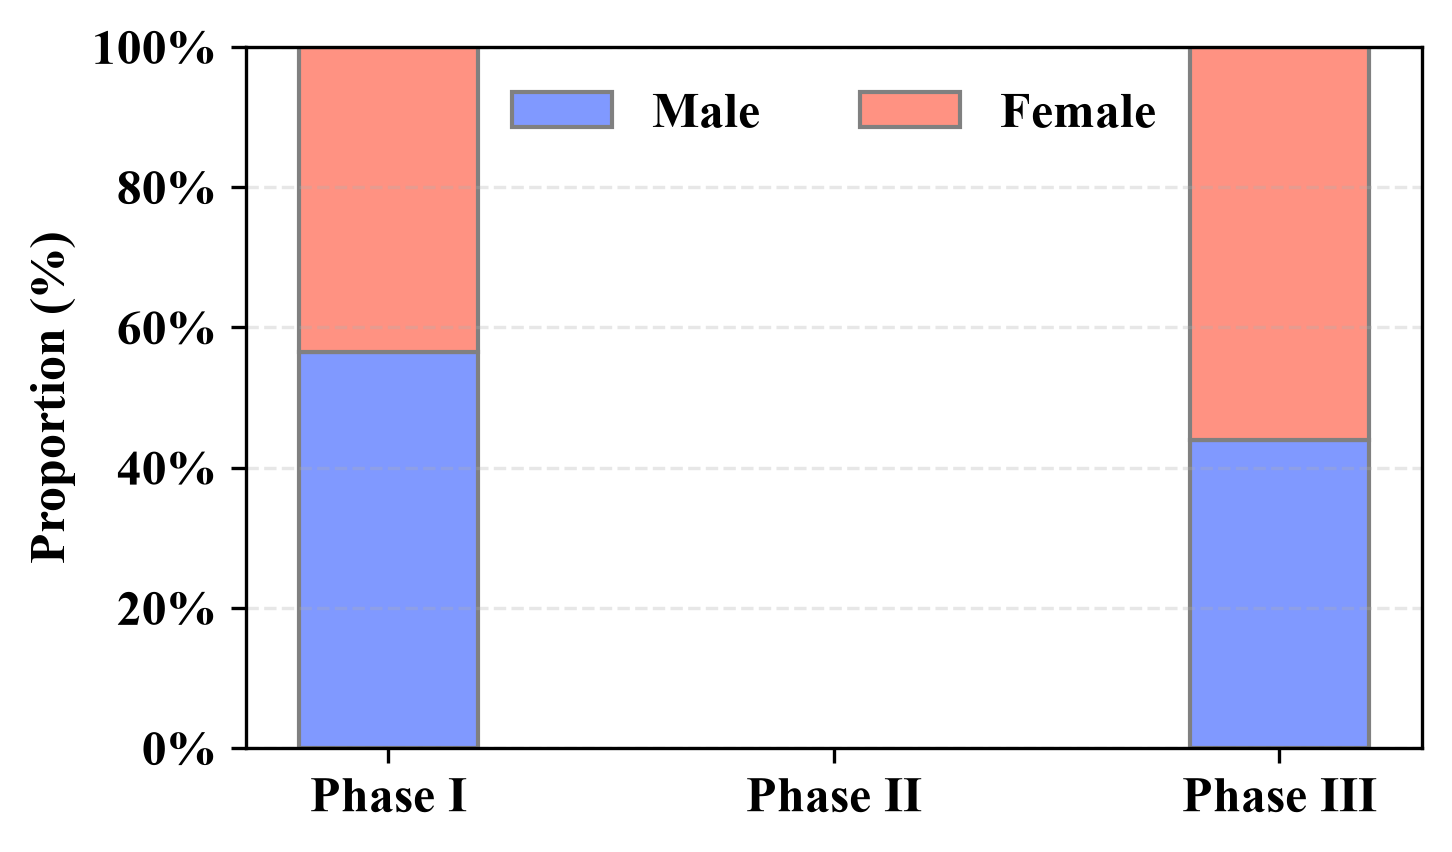

卡方检验结果:
  χ²(1) = 3.489, p = 0.0618
  观察频数: Phase I: [95, 73], Phase III: [43, 55]


In [29]:
# ==================== Fig3B ====================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# 设置绘图样式
plt.rc('font', family='Times New Roman')
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold'})

# 导入数据
plot_data = pd.read_excel('de-identified data.xlsx', sheet_name='Fig3B')

# 准备数据
x = plot_data['Phase']
male_prop = plot_data['Male_count'] / plot_data['Total']
female_prop = plot_data['Female_count'] / plot_data['Total']

# 卡方检验（Phase I vs. Phase III）
observed = [
    [plot_data.loc[0, 'Male_count'], plot_data.loc[0, 'Female_count']],  # Phase I
    [plot_data.loc[2, 'Male_count'], plot_data.loc[2, 'Female_count']]   # Phase III
]
chi2, p, dof, expected = chi2_contingency(observed)

# 绘图
fig, ax = plt.subplots(figsize=(5, 3), dpi=300)
ax.bar(x, male_prop, width=0.4, label='Male', color='#8099FF', edgecolor='grey')
ax.bar(x, female_prop, width=0.4, bottom=male_prop, label='Female', color='#FF9282', edgecolor='grey')

# 添加统计标注
# p_text = f"χ²({dof})={chi2:.2f}, p={p:.3f}{'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''}"
# ax.text(0.5, 1.05, p_text, ha='center', va='bottom', fontsize=9,
#         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='lightgray'))

# 格式设置
ax.set_ylabel('Proportion (%)', fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.2, 0.2))
ax.set_yticklabels([f'{i*100:.0f}%' for i in np.arange(0, 1.2, 0.2)])
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1), ncol=2, frameon=False)

plt.tight_layout()
#plt.savefig('D:\\Research\\Project\\Dengue fever\\DF_nb\\病例性别构成比.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("卡方检验结果:")
print(f"  χ²({dof}) = {chi2:.3f}, p = {p:.4f}")
print(f"  观察频数: Phase I: {observed[0]}, Phase III: {observed[1]}")

#### Fig 3C

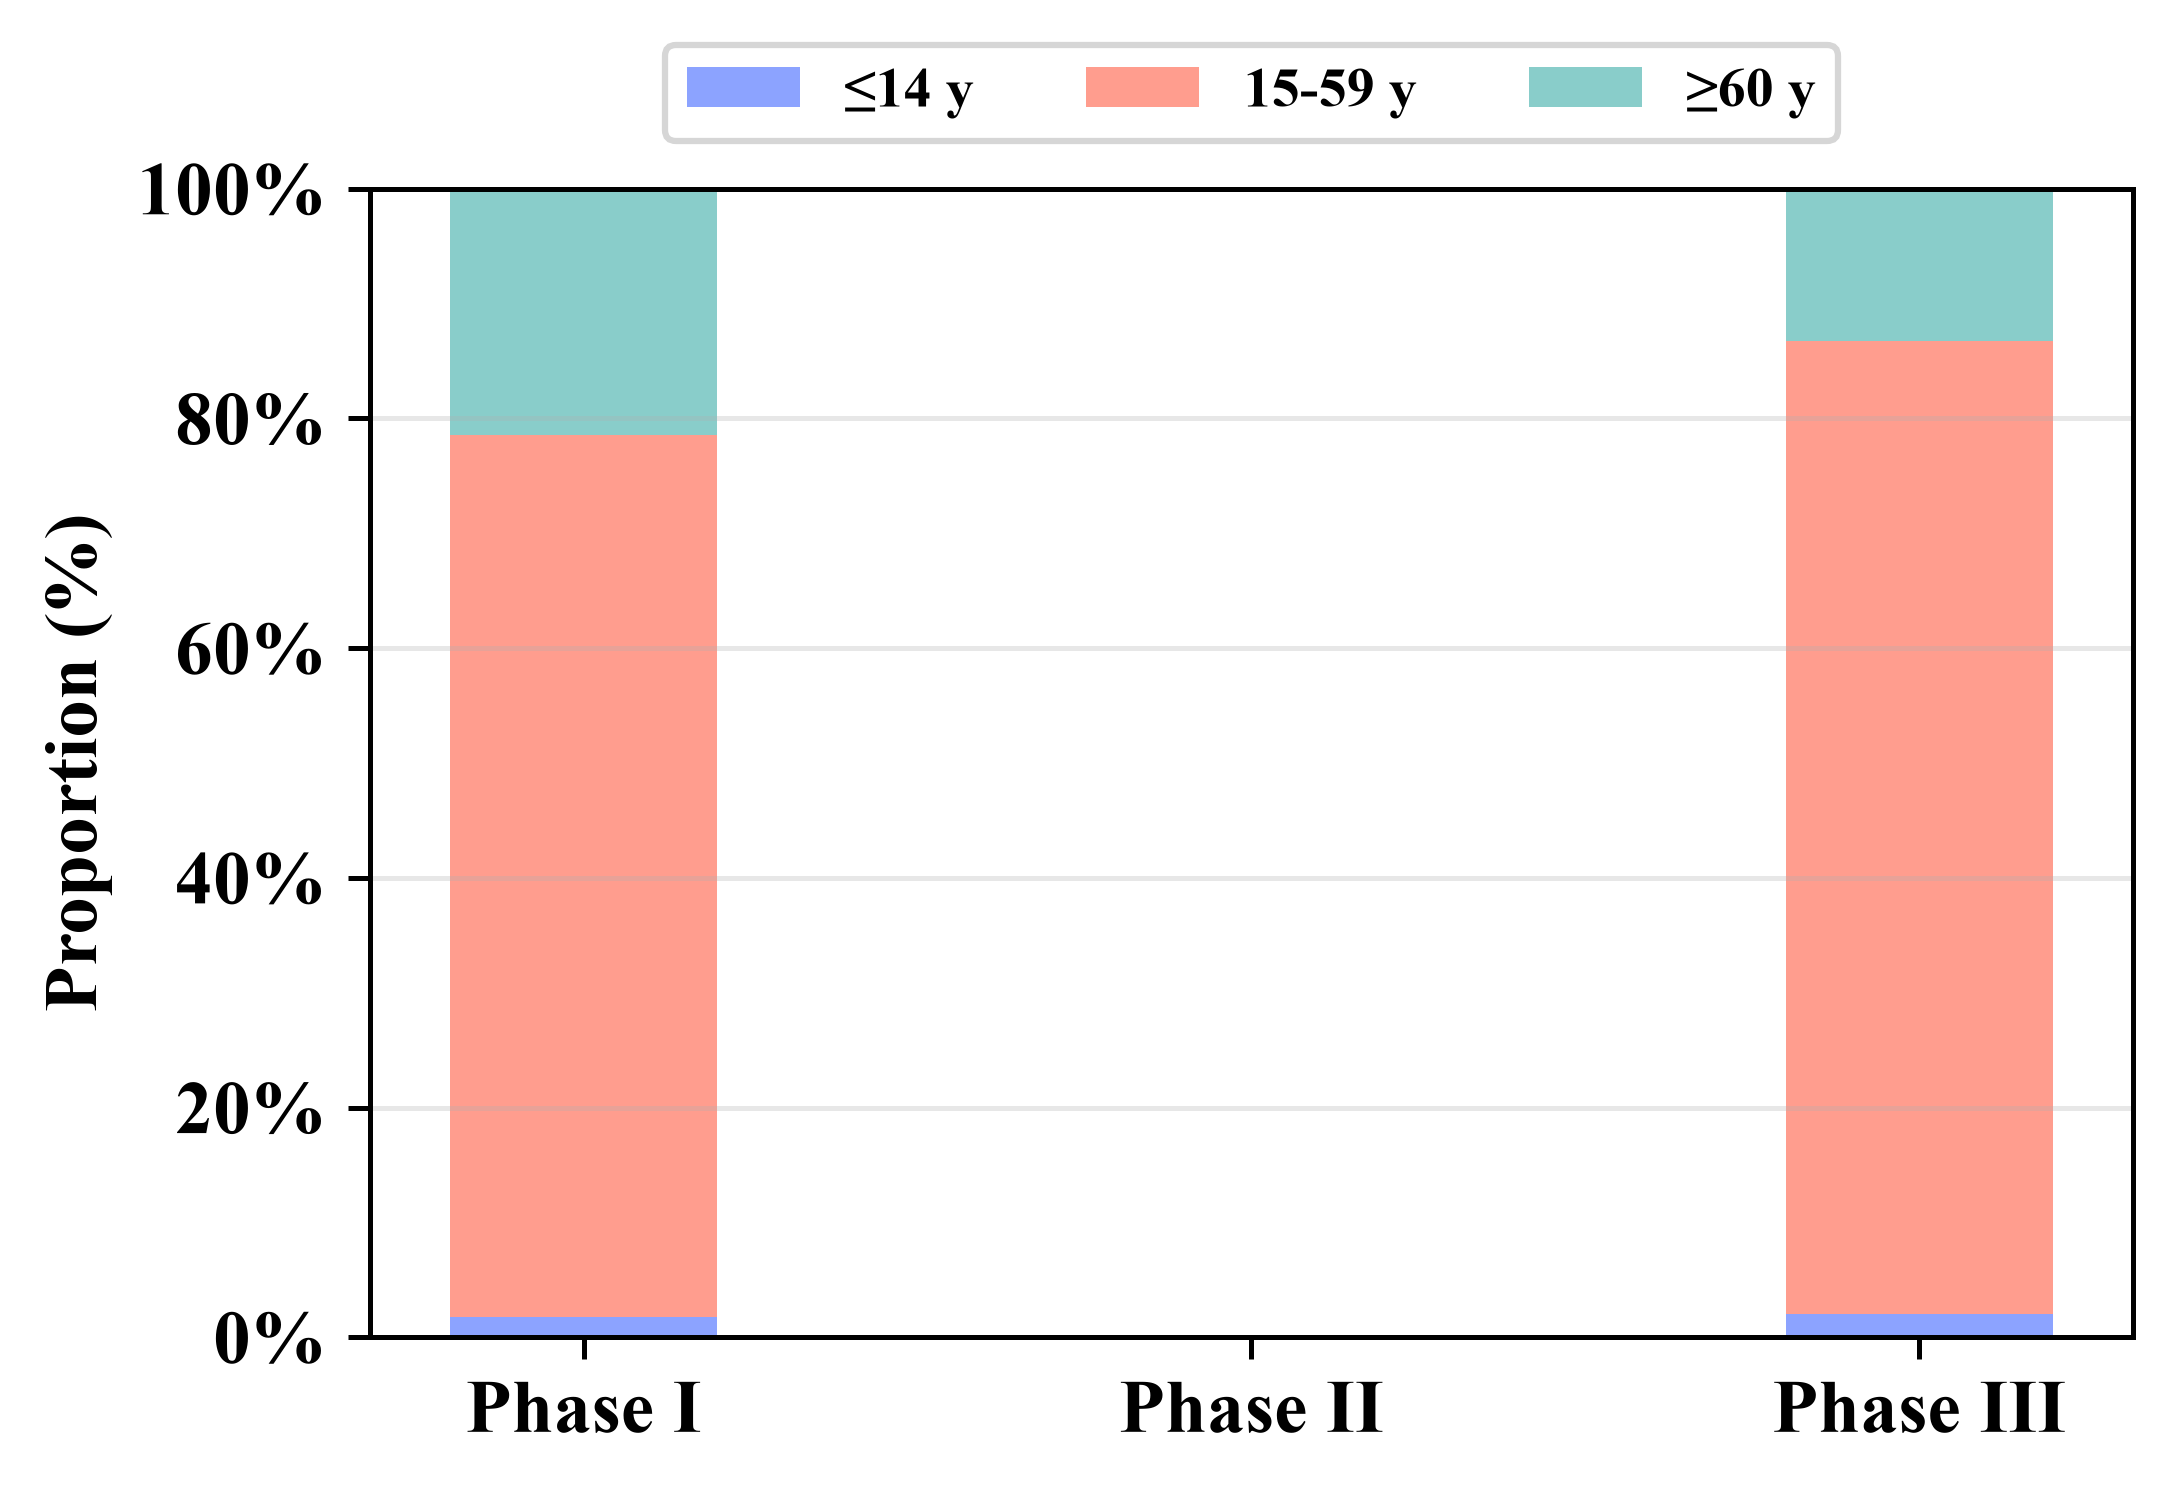

卡方检验结果: χ²(2)=2.7, p=0.253


In [30]:
# ==================== Fig3C ====================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
plt.rc('font', family='Times New Roman')
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold'})
# 1. 导入数据
data = pd.read_excel('de-identified data.xlsx', sheet_name='Fig3C')


# 卡方检验
observed = data[['≤14', '15-59', '≥60']].values

# 自动处理0值
observed_clean = observed[~np.all(observed == 0, axis=1)]
observed_clean = observed_clean[:, ~np.all(observed_clean == 0, axis=0)]

if observed_clean.shape[0] >= 2 and observed_clean.shape[1] >= 2:
    chi2, p, dof, _ = chi2_contingency(observed_clean)
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
    p_text = f"χ²({dof})={chi2:.1f}, p={p:.3f}{sig}"
else:
    p_text = "Insufficient data"

# 绘图
fig, ax = plt.subplots(figsize=(5, 3.5),dpi = 450)

x = data['Phase']
y1, y2, y3 = data['P≤14'], data['P15-59'], data['P≥60']

# 堆叠条形图
colors = ['#8099FF', '#FF9282', '#7CC8C5']
ax.bar(x, y1, width=0.4, label='≤14 y', color=colors[0], alpha=0.9)
ax.bar(x, y2, width=0.4, bottom=y1, label='15-59 y', color=colors[1], alpha=0.9)
ax.bar(x, y3, width=0.4, bottom=y1+y2, label='≥60 y', color=colors[2], alpha=0.9)

# # 数值标签
# for i, (c1, c2, c3, p1, p2, p3) in enumerate(zip(
#     data['≤14'], data['15-59'], data['≥60'],
#     y1, y2, y3
# )):
#     if p1 > 0.05:
#         ax.text(i, p1/2, f'{c1}\n({p1 * 100:.0f}%)', ha='center', va='center', fontsize=8, color='white')
#     if p2 > 0.05:
#         ax.text(i, p1+p2/2, f'{c2}\n({p2 * 100:.0f}%)', ha='center', va='center', fontsize=8, color='white')
#     if p3 > 0.05:
#         ax.text(i, p1+p2+p3/2, f'{c3}\n({p3 * 100:.0f}%)', ha='center', va='center', fontsize=8, color='white')

# # 统计标注
# if "Insufficient" not in p_text:
#     ax.text(0.5, 1.12, p_text, ha='center', va='bottom', fontsize=10,
#             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='lightgray'))

# 坐标轴
ax.set_ylabel('Proportion (%)', fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.2, 0.2))
ax.set_yticklabels([f'{i*100:.0f}%' for i in np.arange(0, 1.2, 0.2)])
ax.grid(axis='y', alpha=0.3)

# 图例
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, fontsize=9)

plt.tight_layout()
#plt.savefig('D:\\Research\\Project\\Dengue fever\\DF_nb\\病例年龄构成比.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"卡方检验结果: {p_text}")

#### Fig 3D


观察频数矩阵形状: (3, 9)
观察频数矩阵:
[[ 3  2  6 20 39 63 20  6  9]
 [ 0  0  0  0  0  0  0  0  0]
 [ 0  3  0  9 23 28 17  7 11]]
警告: 有7个期望频数小于5，卡方检验结果可能不准确

卡方检验结果: χ²(8)=14.03, p=0.081
样本量: 266
自由度: 8
p值: 0.0809

期望频数:
[[ 1.89473684  3.15789474  3.78947368 18.31578947 39.15789474 57.47368421
  23.36842105  8.21052632 12.63157895]
 [ 1.10526316  1.84210526  2.21052632 10.68421053 22.84210526 33.52631579
  13.63157895  4.78947368  7.36842105]]


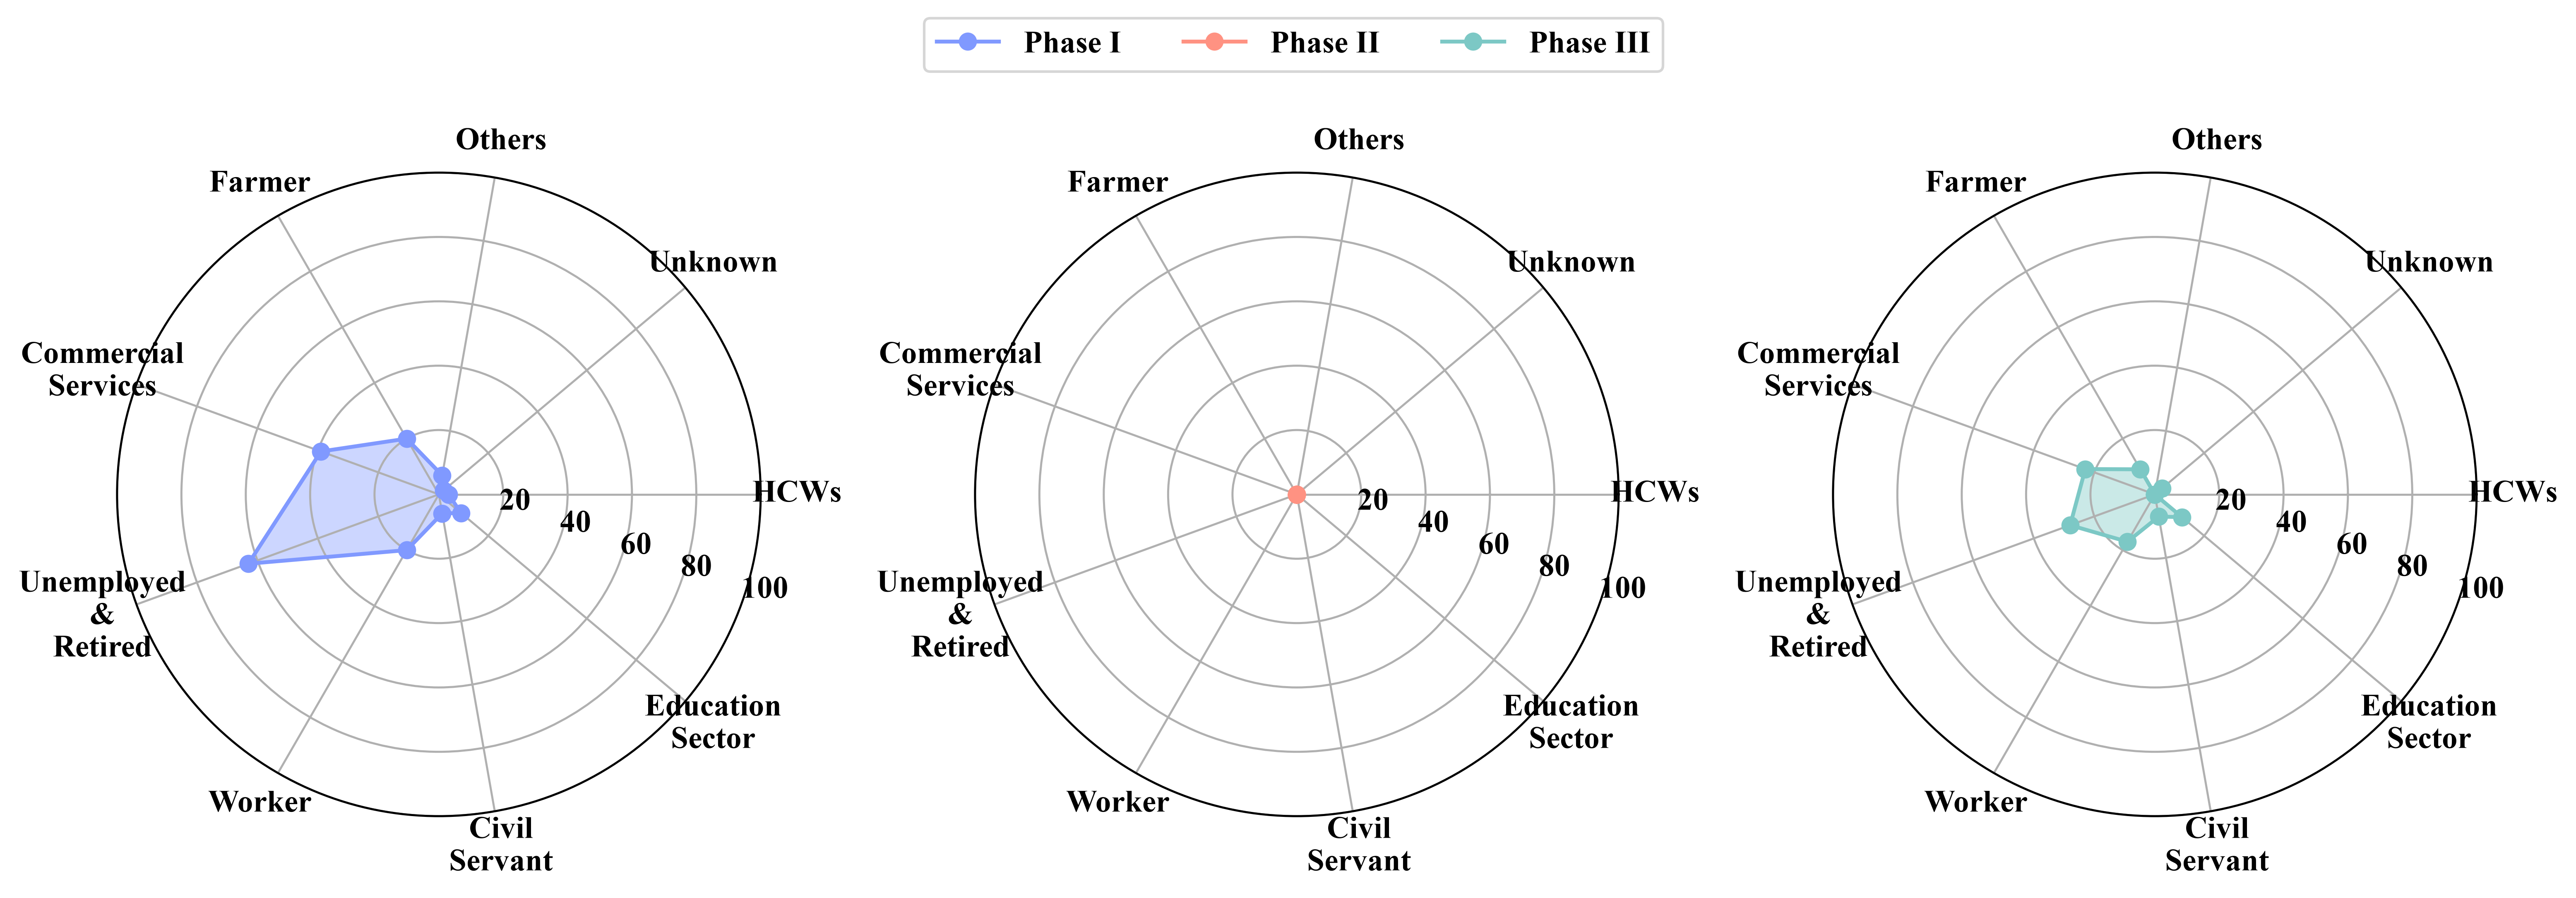

In [31]:
# ==================== Fig3D ====================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 设置样式
plt.rcParams.update({'font.size': 12})

# 从Excel导入数据
data = pd.read_excel('de-identified data.xlsx', sheet_name='Fig3D')

# 提取数据
features = data['Feature'].tolist()
phase_i_values = data['Phase I_value'].tolist()
phase_ii_values = data['Phase II_value'].tolist()
phase_iii_values = data['Phase III_value'].tolist()

 

observed = np.array([phase_i_values, phase_ii_values, phase_iii_values])
print(f"\n观察频数矩阵形状: {observed.shape}")
print("观察频数矩阵:")
print(observed)

# 处理0值
observed_clean = observed.copy()

# 删除全0行
zero_rows = np.all(observed_clean == 0, axis=1)
if zero_rows.any():
    phase_names = ['Phase I', 'Phase II', 'Phase III']
    excluded_rows = [phase_names[i] for i, is_zero in enumerate(zero_rows) if is_zero]
    
    observed_clean = observed_clean[~zero_rows, :]

# 删除全0列
zero_cols = np.all(observed_clean == 0, axis=0)
if zero_cols.any():
    excluded_cols = [features[i] for i, is_zero in enumerate(zero_cols) if is_zero]
     
    observed_clean = observed_clean[:, ~zero_cols]

 

# 检查数据是否适合卡方检验
if observed_clean.shape[0] >= 2 and observed_clean.shape[1] >= 2:
    # 执行卡方检验
    chi2, p, dof, expected = chi2_contingency(observed_clean)
    n = observed_clean.sum()
    
    # 检查样本量和期望频数
    warnings = []
    if n < 20:
        warnings.append(f"样本量较小(n={n})")
    
    if (expected < 5).any():
        low_count = np.sum(expected < 5)
        warnings.append(f"有{low_count}个期望频数小于5")
    
    if warnings:
        print(f"警告: {'; '.join(warnings)}，卡方检验结果可能不准确")
    
    # 格式化p值
    if p < 0.001:
        p_text = f"χ²({dof})={chi2:.2f}, p<0.001***"
    elif p < 0.01:
        p_text = f"χ²({dof})={chi2:.2f}, p={p:.3f}**"
    elif p < 0.05:
        p_text = f"χ²({dof})={chi2:.2f}, p={p:.3f}*"
    else:
        p_text = f"χ²({dof})={chi2:.2f}, p={p:.3f}"
    
    print(f"\n卡方检验结果: {p_text}")
    print(f"样本量: {n}")
    print(f"自由度: {dof}")
    print(f"p值: {p:.4f}")
    print(f"\n期望频数:")
    print(expected)
else:
    print(f"\n数据不足，无法进行卡方检验")
    p_text = "Insufficient data for chi-square test"
    chi2, p, dof, expected = np.nan, np.nan, np.nan, np.array([])

# ==================== 绘制雷达图 ====================
fig, axs = plt.subplots(1, 3, figsize=(14, 6), dpi=450, subplot_kw=dict(polar=True))

# 准备数据
times = ['Phase I', 'Phase II', 'Phase III']
colors = ['#8099FF', '#FF9282', '#7CC8C5']
values = [phase_i_values, phase_ii_values, phase_iii_values]

# 处理特征标签（换行）
feature_with_break = [f.replace(' ', '\n') for f in features]

# 计算角度
angles = np.linspace(0, 2*np.pi, len(features), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

for i, ax in enumerate(axs.flat):
    val = values[i]
    val = np.concatenate((val, [val[0]]))
    color = colors[i]
    
    # 绘制雷达图
    ax.plot(angles, val, 'o-', linewidth=1.5, color=color, label=times[i])
    ax.fill(angles, val, alpha=0.4, color=color)
    
    # 设置刻度
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_with_break, verticalalignment='center', 
                       horizontalalignment='center', fontsize=12)
    
    # 设置范围
    ax.set_ylim(0, 100)
    ax.grid(True)
    ax.set_rlabel_position(-20)
    
    # 添加阶段标题
   # ax.set_title(times[i], fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()

# # 添加整体标题和统计结果
# if 'p_text' in locals() and not p_text.startswith("Insufficient"):
#     plt.figtext(0.5, 1.05, f"Occupation Distribution\n{p_text}", 
#                 ha='center', fontsize=12, fontweight='bold',
#                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray'))

plt.subplots_adjust(top=0.85)

fig.legend(loc='upper right', bbox_to_anchor=(0.65, 0.88), ncol=4)
#plt.savefig('D:\\Research\\Project\\Dengue fever\\DF_nb\\病例职业构成比.pdf', dpi=300, bbox_inches='tight')
plt.show()



#### Fig 3E

Kruskal-Wallis H-test results (excluding Phase II):
H = 18.437, p = 0.0001

Post-hoc pairwise comparisons (Mann-Whitney U with Bonferroni correction):
Phase I (DC1) vs Phase I (DC2): U = 1196.5, p = 0.0330, adj_p = 0.0989 ns
Phase I (DC1) vs Phase III: U = 816.0, p = 0.0054, adj_p = 0.0162 *
Phase I (DC2) vs Phase III: U = 9760.5, p = 0.0003, adj_p = 0.0009 *


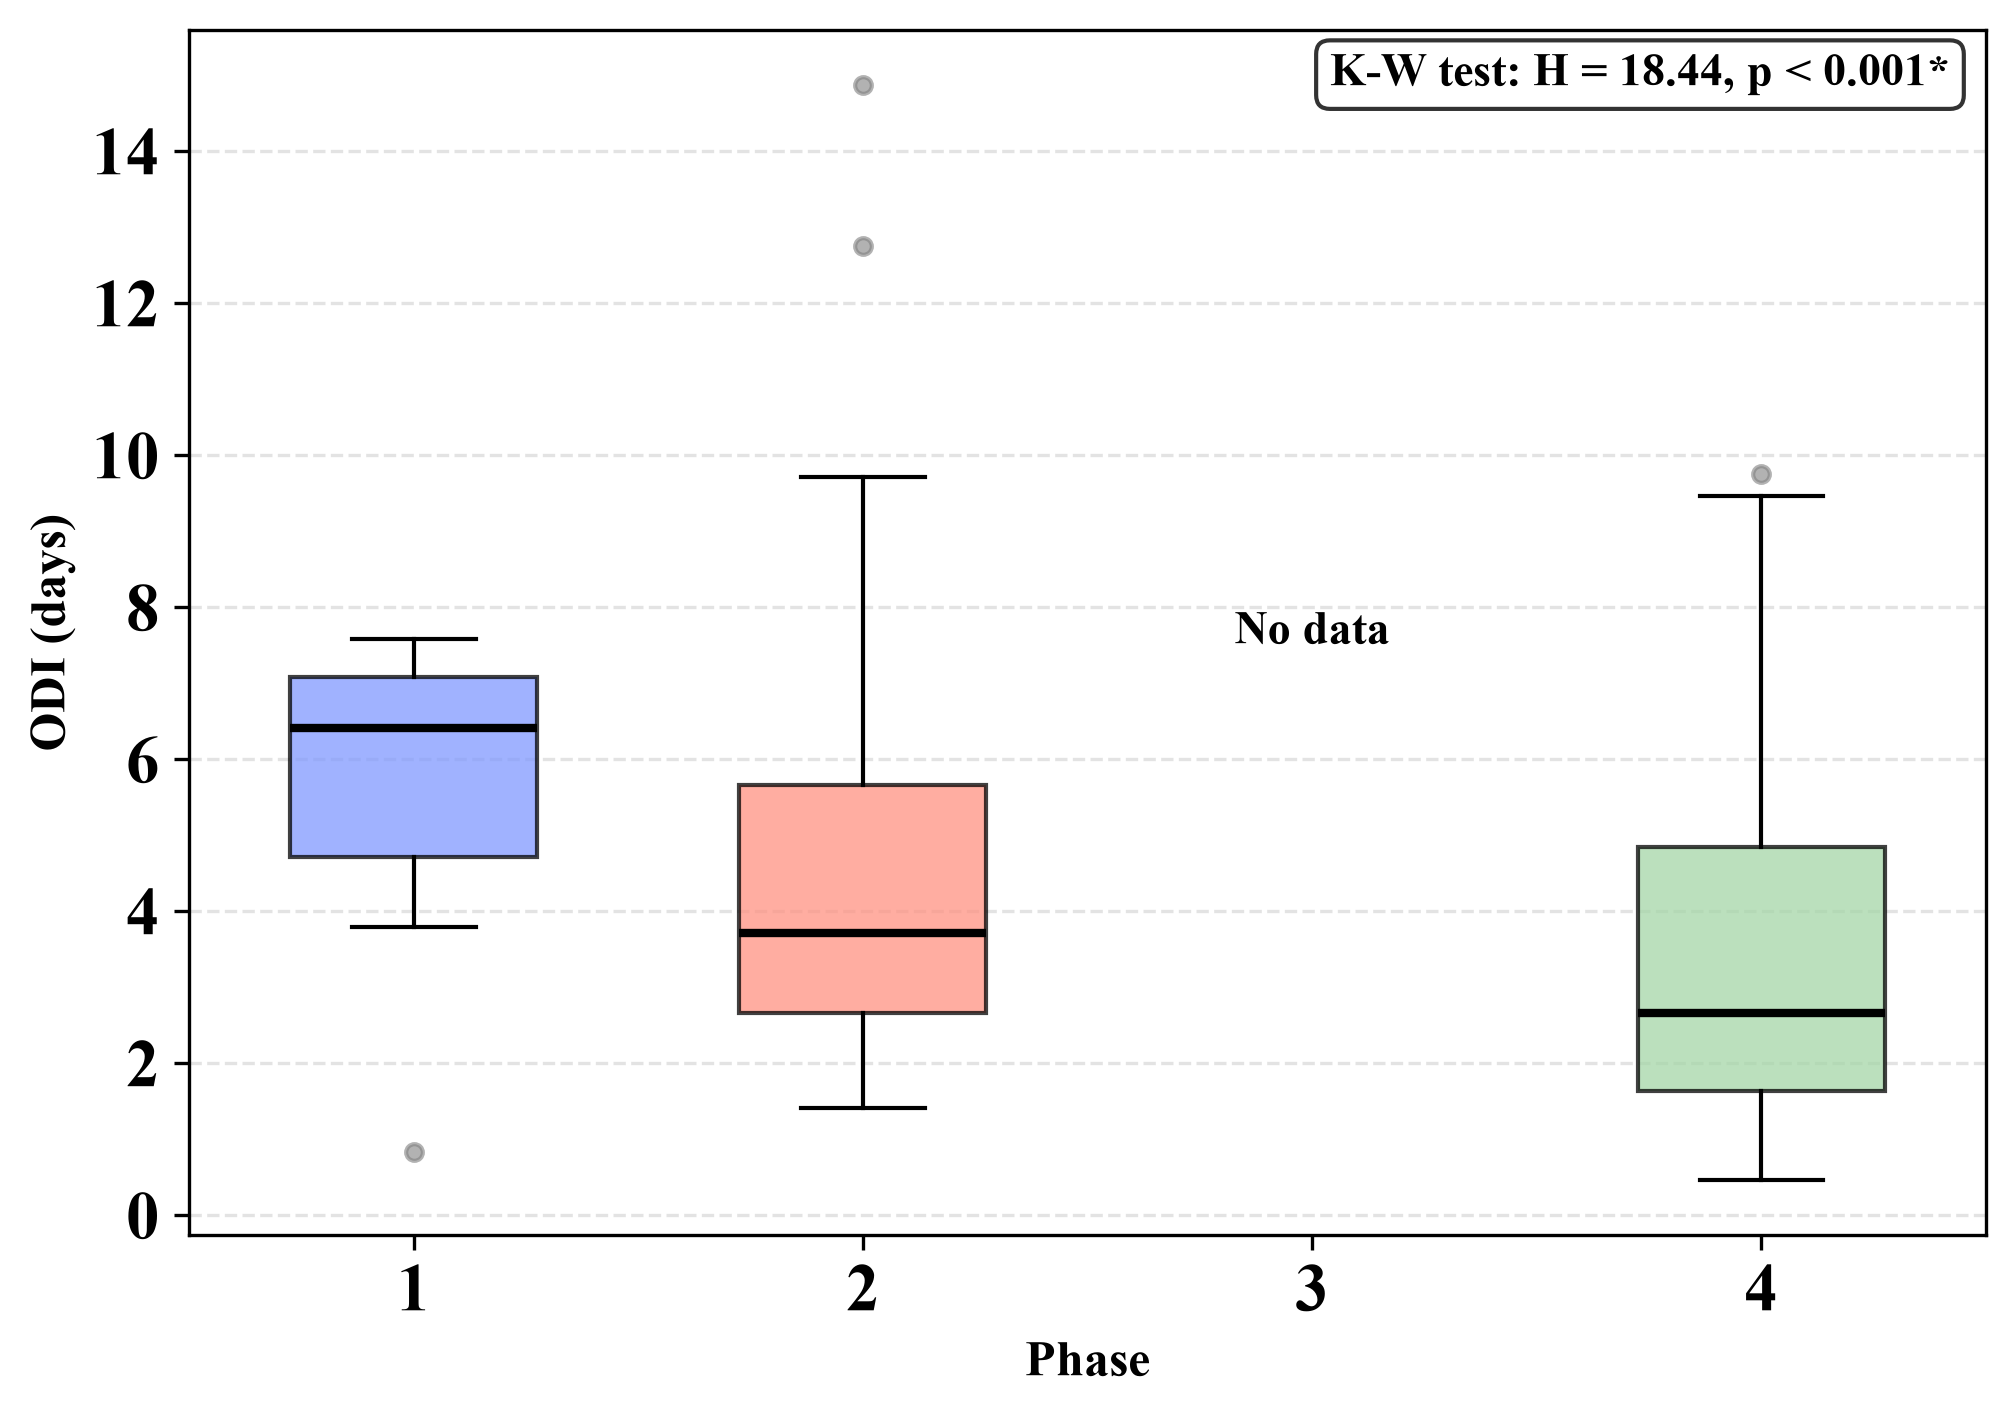

In [ ]:
# ==================== Fig3E ====================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats

# 设置样式
plt.rc('font', family='Times New Roman')
plt.rcParams.update({'font.size': 16})

df_wide = pd.read_excel('de-identified data.xlsx', sheet_name='Fig3E')


phase_order = ['Phase I (DC1)', 'Phase I (DC2)', 'Phase II (DC2)', 'Phase III (DC2)']

# 用于显示的多行标签
phase_labels = ['Phase I\n(DC1)', 'Phase I\n(DC2)', 'Phase II\n(DC2)', 'Phase III\n(DC2)']
data_by_phase = [df_wide[col].dropna().astype(float).values for col in phase_order]

# 准备K-W检验的数据（排除Phase II，因为它没有数据）
valid_phases = ['Phase I (DC1)', 'Phase I (DC2)', 'Phase III']
valid_data = []
for i, ph in enumerate(phase_order):
    if ph != 'Phase II (DC2)':  # 跳过Phase II
        valid_data.append(data_by_phase[i])

# 进行Kruskal-Wallis检验
kw_stat, kw_p = stats.kruskal(*valid_data)
print(f"Kruskal-Wallis H-test results (excluding Phase II):")
print(f"H = {kw_stat:.3f}, p = {kw_p:.4f}")

# 如果需要事后两两比较（Mann-Whitney U检验）
if kw_p < 0.05:
    print("\nPost-hoc pairwise comparisons (Mann-Whitney U with Bonferroni correction):")
    comparisons = []
    for i in range(len(valid_phases)):
        for j in range(i+1, len(valid_phases)):
            u_stat, p_val = stats.mannwhitneyu(valid_data[i], valid_data[j], alternative='two-sided')
            comparisons.append((valid_phases[i], valid_phases[j], u_stat, p_val))
    
    # Bonferroni校正
    bonferroni_correction = len(comparisons)
    for comp in comparisons:
        adj_p = comp[3] * bonferroni_correction
        sig_star = '*' if adj_p < 0.05 else 'ns'
        print(f"{comp[0]} vs {comp[1]}: U = {comp[2]:.1f}, p = {comp[3]:.4f}, adj_p = {adj_p:.4f} {sig_star}")

# Plot settings
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
phase_colors = ['#8099FF', '#FF9282', '#7CC8C5', '#A5D6A7']

boxes = ax.boxplot(
    data_by_phase,
    tick_labels=phase_labels, 
    patch_artist=True,
    widths=0.55,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=4, markerfacecolor='gray', markeredgecolor='gray', alpha=0.6)
)

for patch, color in zip(boxes['boxes'], phase_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Keep Phase II slot even if no data
for i, ph in enumerate(phase_order):
    n_i = len(data_by_phase[i])
    if n_i == 0:
        ax.text(i + 1, 0.5, 'No data', ha='center', va='center', fontsize=11, fontweight='bold', transform=ax.get_xaxis_transform())

# # n labels
# y_top = ax.get_ylim()[1]
# for i, ph in enumerate(phase_order):
#     n_i = len(data_by_phase[i])
#     if n_i > 0:  # 只显示有数据的n值
#         ax.text(i + 1, y_top * 0.97, f'n={n_i}', ha='center', va='top', fontsize=10, fontweight='bold')

# 添加K-W检验结果到图上
kw_text = f'K-W test: H = {kw_stat:.2f}, p = {kw_p:.4f}'
if kw_p < 0.001:
    kw_text = f'K-W test: H = {kw_stat:.2f}, p < 0.001*'
elif kw_p < 0.01:
    kw_text = f'K-W test: H = {kw_stat:.2f}, p = {kw_p:.3f}*'
else:
    kw_text = f'K-W test: H = {kw_stat:.2f}, p = {kw_p:.3f}*'

# 在图的右上角添加K-W检验结果
ax.text(0.98, 0.98, kw_text, transform=ax.transAxes, 
        ha='right', va='top', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))




ax.set_xlabel('Phase', fontsize=12, fontweight='bold')
ax.set_ylabel('ODI (days)', fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.35)

for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontname('Times New Roman')
    tick.set_fontweight('bold')

plt.tight_layout()
#plt.savefig('D:\\Research\\Project\\Dengue fever\\DF_nb\\ODI分布.pdf', dpi=300, bbox_inches='tight')
plt.show()



#### Fig 3F

全0列检测:
  Phase I: Yes=30, No=138, 全0=False
  Phase II: Yes=0, No=0, 全0=True
  Phase III: Yes=62, No=36, 全0=False

发现全0列: ['Phase II']
删除这些列...
卡方检验结果: χ²(1)=54.42, p<0.001***


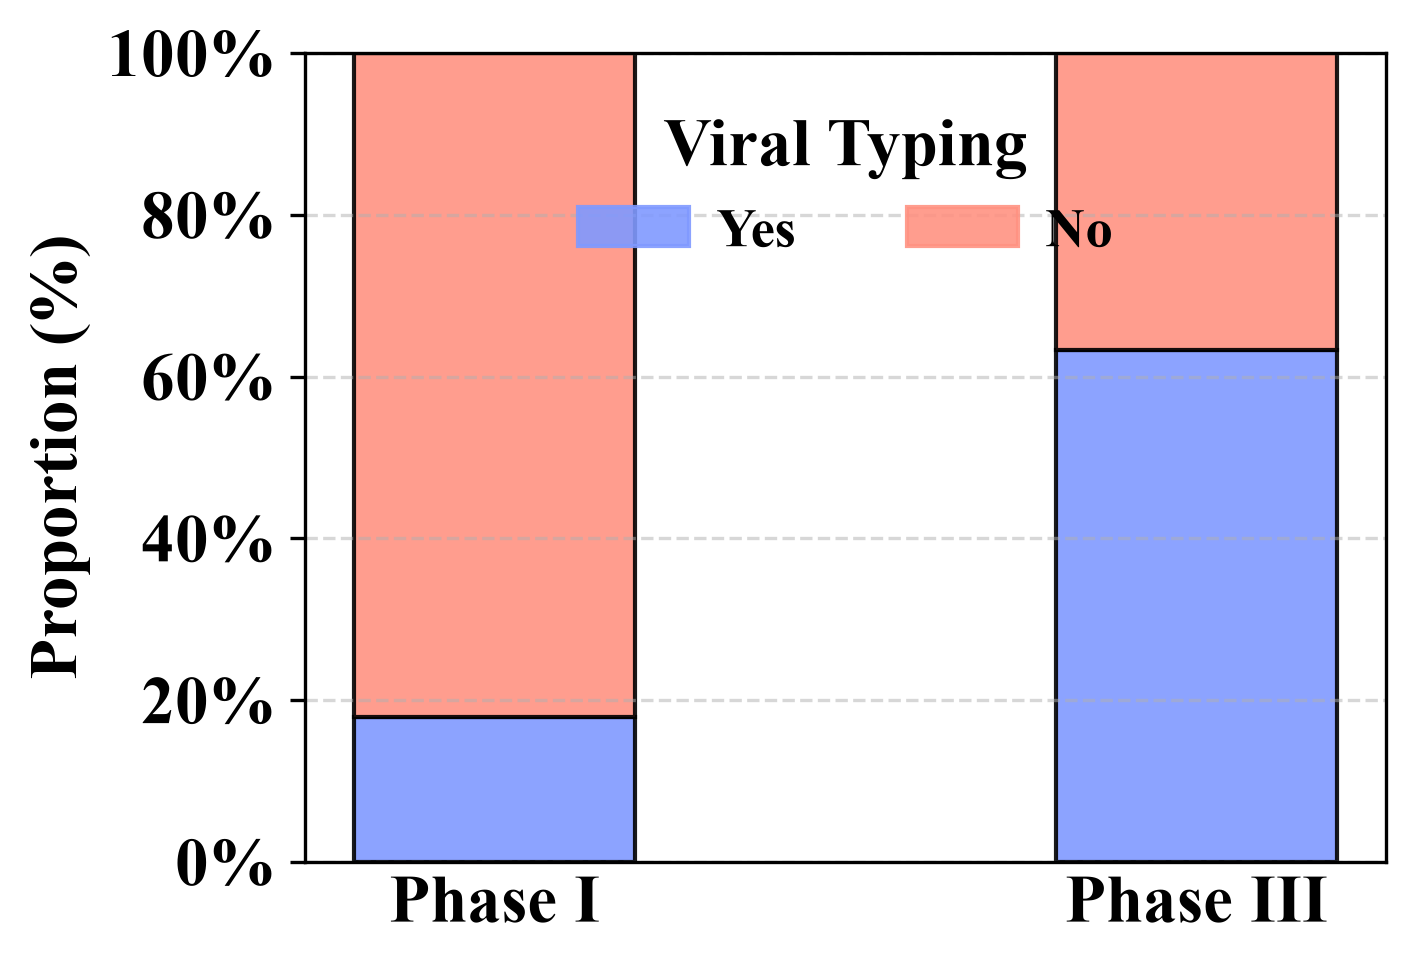

In [33]:
# ==================== 费希尔精确检验替代卡方检验 ====================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact

# 导入数据
data = pd.read_excel('de-identified data.xlsx', sheet_name='Fig3F')


# 提取数据
x = data['Phase'].values
no_counts = data['No_count'].values
yes_counts = data['Yes_count'].values
total_counts = data['Total'].values
no_prop = data['No_proportion'].values
yes_prop = data['Yes_proportion'].values


# 创建观察频数表（行：Yes/No，列：Phase）
observed = np.array([yes_counts, no_counts])


# 找出全0列（即Yes_count和No_count都为0的列）
zero_cols = np.all(observed == 0, axis=0)
print(f"全0列检测:")
for i, is_zero in enumerate(zero_cols):
    print(f"  {x[i]}: Yes={yes_counts[i]}, No={no_counts[i]}, 全0={is_zero}")

if zero_cols.any():
    print(f"\n发现全0列: {x[zero_cols].tolist()}")
    print("删除这些列...")
    
    # 删除全0列
    observed_clean = observed[:, ~zero_cols]
    x_clean = x[~zero_cols]
    yes_counts_clean = yes_counts[~zero_cols]
    no_counts_clean = no_counts[~zero_cols]
    yes_prop_clean = yes_prop[~zero_cols]
    no_prop_clean = no_prop[~zero_cols]
    total_counts_clean = total_counts[~zero_cols]
  
else:
    observed_clean = observed.copy()
    x_clean = x.copy()
    yes_counts_clean = yes_counts.copy()
    no_counts_clean = no_counts.copy()
    yes_prop_clean = yes_prop.copy()
    no_prop_clean = no_prop.copy()
    total_counts_clean = total_counts.copy()
    print("没有发现全0列")


# 检查处理后是否有足够的数据进行卡方检验
if observed_clean.shape[1] < 2:
    print("警告: 删除全0列后少于2列，无法进行卡方检验")
    p_text = "Insufficient data for chi-square test (less than 2 phases after removing zeros)"
    chi2, p, dof, expected = np.nan, np.nan, np.nan, np.array([])
else:
    # 执行卡方检验
    try:
        chi2, p, dof, expected = chi2_contingency(observed_clean)
        n = observed_clean.sum()
        
        # 检查样本量
        if n < 20:
            print(f"警告: 样本量较小(n={n})，卡方检验结果可能不准确")
        
        # 检查期望频数
        if (expected < 5).any():
            low_count = np.sum(expected < 5)
            print(f"警告: 有{low_count}个期望频数小于5，卡方检验结果可能不准确")
        
        # 格式化p值
        if p < 0.001:
            p_text = f"χ²({dof})={chi2:.2f}, p<0.001***"
        elif p < 0.01:
            p_text = f"χ²({dof})={chi2:.2f}, p={p:.3f}**"
        elif p < 0.05:
            p_text = f"χ²({dof})={chi2:.2f}, p={p:.3f}*"
        else:
            p_text = f"χ²({dof})={chi2:.2f}, p={p:.3f}"
        
        print(f"卡方检验结果: {p_text}")
        # print(f"样本量: {n}")
        # # print(f"自由度: {dof}")
        # print(f"p值: {p:.4f}")
        # print(f"\n期望频数表:")
        # print(expected)
        
    except Exception as e:
        print(f"卡方检验失败: {e}")
        p_text = "Chi-square test failed"
        chi2, p, dof, expected = np.nan, np.nan, np.nan, np.array([])



# 绘图
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=300)

# 堆叠条形图
colors = ['#8099FF', '#FF9282']

# 绘制每个阶段的条形
for i in range(len(x_clean)):
    # Yes部分
    ax.bar(i, yes_prop_clean[i], width=0.4, 
           label='Yes' if i == 0 else "", 
           color=colors[0], edgecolor='black', alpha=0.9)
    
    # No部分（堆叠在Yes上面）
    ax.bar(i, no_prop_clean[i], width=0.4, bottom=yes_prop_clean[i],
           label='No' if i == 0 else "", 
           color=colors[1], edgecolor='black', alpha=0.9)
    
    # # 添加数值标签
    # if yes_prop_clean[i] > 0.05:  # 只显示大于5%的部分
    #     ax.text(i, yes_prop_clean[i]/2, 
    #             f'{yes_counts_clean[i]}\n({yes_prop_clean[i]*100:.1f}%)', 
    #             ha='center', va='center', fontsize=8, 
    #             color='white', fontweight='bold')
    
    # if no_prop_clean[i] > 0.05:
    #     ax.text(i, yes_prop_clean[i] + no_prop_clean[i]/2, 
    #             f'{no_counts_clean[i]}\n({no_prop_clean[i]*100:.1f}%)', 
    #             ha='center', va='center', fontsize=8, 
    #             color='white', fontweight='bold')

# 设置x轴刻度
ax.set_xticks(range(len(x_clean)))
ax.set_xticklabels(x_clean)
ax.tick_params(axis='x', length=0)

# 坐标轴设置
ax.set_ylabel('Proportion (%)', fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.2, 0.2))
ax.set_yticklabels([f'{i*100:.0f}%' for i in np.arange(0, 1.2, 0.2)])
ax.grid(axis='y', alpha=0.5, ls='--')

# # 添加统计标注
# if 'p_text' in locals() and not p_text.startswith(("Insufficient", "Chi-square")):
#     ax.text(0.5, 1.12, p_text, ha='center', va='bottom', fontsize=10,
#             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
#                      edgecolor='silver', alpha=0.9))
# elif zero_cols.any():
#     excluded_phases = x[zero_cols].tolist()
#     ax.text(0.5, 1.12, f"Note: {len(excluded_phases)} phase(s) excluded: {', '.join(excluded_phases)}", 
#             ha='center', va='bottom', fontsize=9,
#             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
#                      edgecolor='silver', alpha=0.9))

# 图例
handles = [
    plt.Rectangle((0,0),1,1, color=colors[0], alpha=0.9),
    plt.Rectangle((0,0),1,1, color=colors[1], alpha=0.9)
]
ax.legend(handles, ['Yes', 'No'],
          title = 'Viral Typing',
          loc='upper center',
          bbox_to_anchor=(0.5, 0.98),
          ncol=2,
          fontsize='small',
          frameon=False,
          handletextpad=0.5)

plt.tight_layout()
#plt.savefig('D:\\Research\\Project\\Dengue fever\\DF_nb\\病毒分型分布.pdf', dpi=300, bbox_inches='tight')
plt.show()

#### Fig 3G

卡方检验结果: χ²(2) = 0.16, p = 0.9250


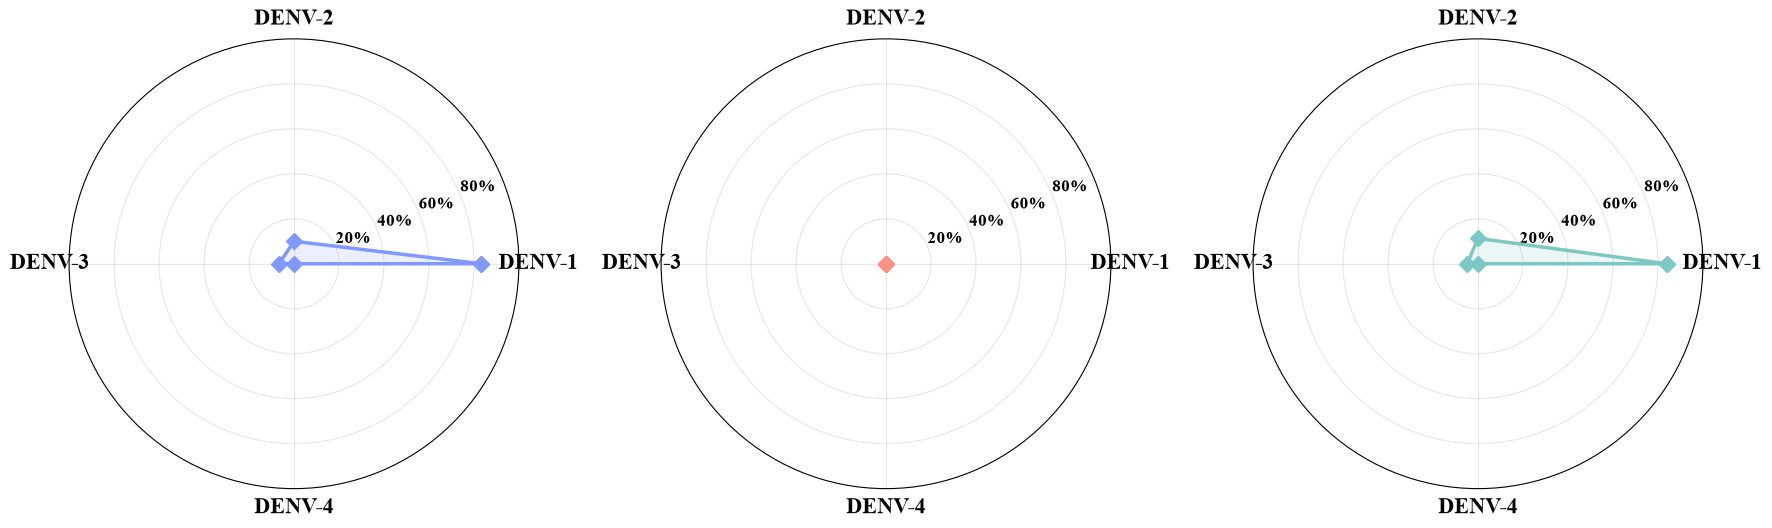

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# 1. 数据加载
df = pd.read_excel('de-identified data.xlsx', sheet_name='Fig3G')
variant_cols = ['DENV-1', 'DENV-2', 'DENV-3', 'DENV-4']
phases = df['Phase'].tolist()
count_data = df[variant_cols].values

# 2. 数据预处理（移除全零行/列）
chi2_data = df[variant_cols].copy()
chi2_data_clean = chi2_data[(chi2_data != 0).any(axis=1)]  # 移除全零行
chi2_data_final = chi2_data_clean.loc[:, (chi2_data_clean != 0).any(axis=0)]  # 移除全零列

# 3. 标准卡方检验
if chi2_data_final.shape[0] >= 2 and chi2_data_final.shape[1] >= 2:
    chi2_stat, p_value, dof, expected = chi2_contingency(chi2_data_final.values, correction=False)
    print(f"卡方检验结果: χ²({dof}) = {chi2_stat:.2f}, p = {p_value:.4f}")
else:
    print("数据不足，无法进行卡方检验")
    p_value = None

# 4. 可视化（百分比构成图）
fig, axes = plt.subplots(1, len(phases), figsize=(6*len(phases), 8), subplot_kw={'polar': True})
if len(phases) == 1:
    axes = [axes]

# 计算百分比
percent_data = np.array([[x/sum(row)*100 if sum(row)>0 else 0 for x in row] for row in count_data])
angles = np.linspace(0, 2*np.pi, len(variant_cols), endpoint=False).tolist()
angles += angles[:1]

colors = ['#8099FF', '#FF9282', '#7CC8C5', '#FFC154', '#4ECDC4', '#FF6B6B']
phase_colors = colors[:len(phases)]

for idx, phase in enumerate(phases):
    ax = axes[idx]
    values = percent_data[idx]
    counts = count_data[idx]
    closed_values = list(values) + [values[0]]
    
    ax.fill(angles, closed_values, color=phase_colors[idx], alpha=0.15)
    ax.plot(angles, closed_values, color=phase_colors[idx], linewidth=2.5, marker='D', markersize=8)
    
  
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(variant_cols, rotation=30, fontdict={'fontsize': 16, 'fontweight': 'bold'})
    ax.set_yticks([20, 40, 60, 80])
    ax.set_yticklabels(['20%', '40%', '60%', '80%'], fontsize=12)
    ax.set_ylim(0, 100)
   # ax.set_title(f'{phase}\n(n={sum(counts)})', pad=25, fontdict={'fontsize': 14, 'fontweight': 'bold'})
    ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('D:\\Research\\Project\\Dengue fever\\DF_nb\\登革病毒分布.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Figure 4

#### Fig 4A

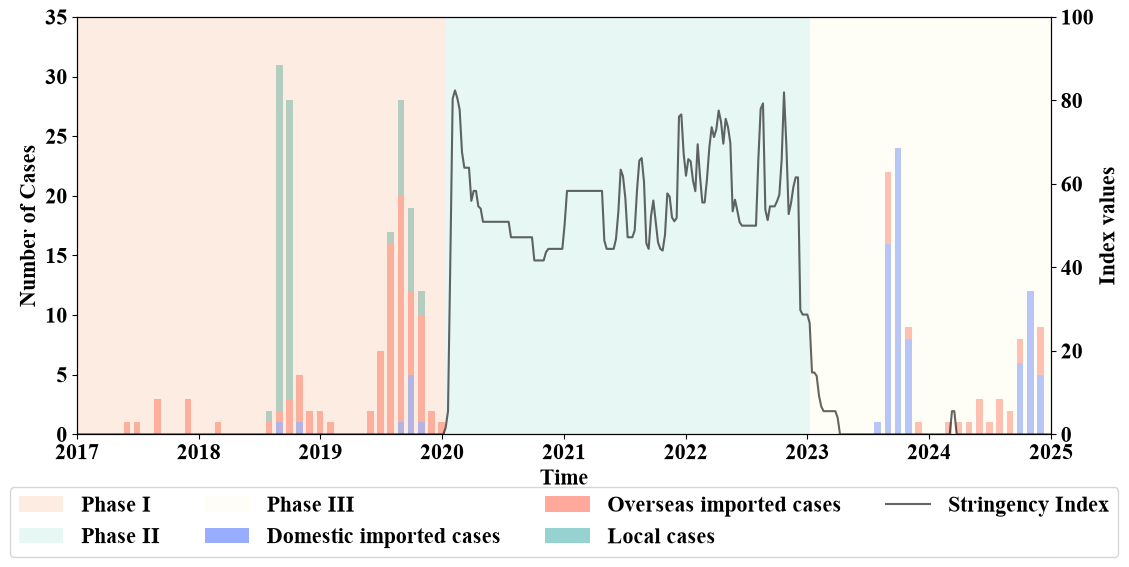

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_excel("de-identified data.xlsx", sheet_name='Fig4A')
df['Date'] = pd.to_datetime(df['Date'])


# 创建图形
fig, ax1 = plt.subplots(figsize=(12, 6))

# 提取非空数据
# 病例数据
case_mask = df[['Domestic imported cases', 'International imported cases', 'Local cases']].notna().any(axis=1)
case_data = df[case_mask]

# Stringency Index数据
stringency_mask = df['Stringency Index'].notna()
stringency_data = df[stringency_mask]

# 绘制堆叠柱状图
if not case_data.empty:
    bar_width = 20
    bottom1 = np.zeros(len(case_data))
    bottom2 = case_data['Domestic imported cases'].fillna(0)
    
    ax1.bar(case_data['Date'], case_data['Domestic imported cases'].fillna(0), 
            color='#8099FF', label='Domestic imported cases', 
            width=bar_width, alpha=0.8, edgecolor='none')
    ax1.bar(case_data['Date'], case_data['International imported cases'].fillna(0), 
            bottom=bottom2, color='#FF9282', label='Overseas imported cases', 
            width=bar_width, alpha=0.8, edgecolor='none')
    ax1.bar(case_data['Date'], case_data['Local cases'].fillna(0), 
            bottom=bottom2 + case_data['International imported cases'].fillna(0), 
            color='#7CC8C5', label='Local cases', 
            width=bar_width, alpha=0.8, edgecolor='none')

# 设置坐标轴
ax1.set_xlabel("Time", fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax1.set_ylabel("Number of Cases", fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax1.set_xlim(pd.Timestamp('2017-01-01'), pd.Timestamp('2025-01-01'))
ax1.set_ylim(0, 35)
ax1.set_yticks(np.arange(0, 36, 5))

# 添加阶段背景色
ax1.axvspan(pd.Timestamp('2017-01-01'), pd.Timestamp('2020-01-14'), 
            facecolor='#F7C2A0', alpha=0.3, label='Phase I')
ax1.axvspan(pd.Timestamp('2020-01-14'), pd.Timestamp('2023-01-08'), 
            facecolor='#0DB194', alpha=0.1, label='Phase II')
ax1.axvspan(pd.Timestamp('2023-01-08'), pd.Timestamp('2025-01-01'), 
            facecolor='#FEFEE6', alpha=0.3, label='Phase III')

# 创建次坐标轴
ax2 = ax1.twinx()

# 绘制Stringency Index折线
if not stringency_data.empty:
    ax2.plot(stringency_data['Date'], stringency_data['Stringency Index'], 
             color='k', label='Stringency Index', linewidth=1.5, alpha=0.6)

ax2.set_ylabel("Index values", fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax2.set_ylim(0, 100)

# 添加图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines = lines1 + lines2
labels = labels1 + labels2
plt.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

plt.tight_layout()
#plt.savefig('D:\\Research\\Project\\Dengue fever\\DF_nb\\流行曲线.pdf', dpi=300, bbox_inches='tight')
plt.show()

#### Fig 4B

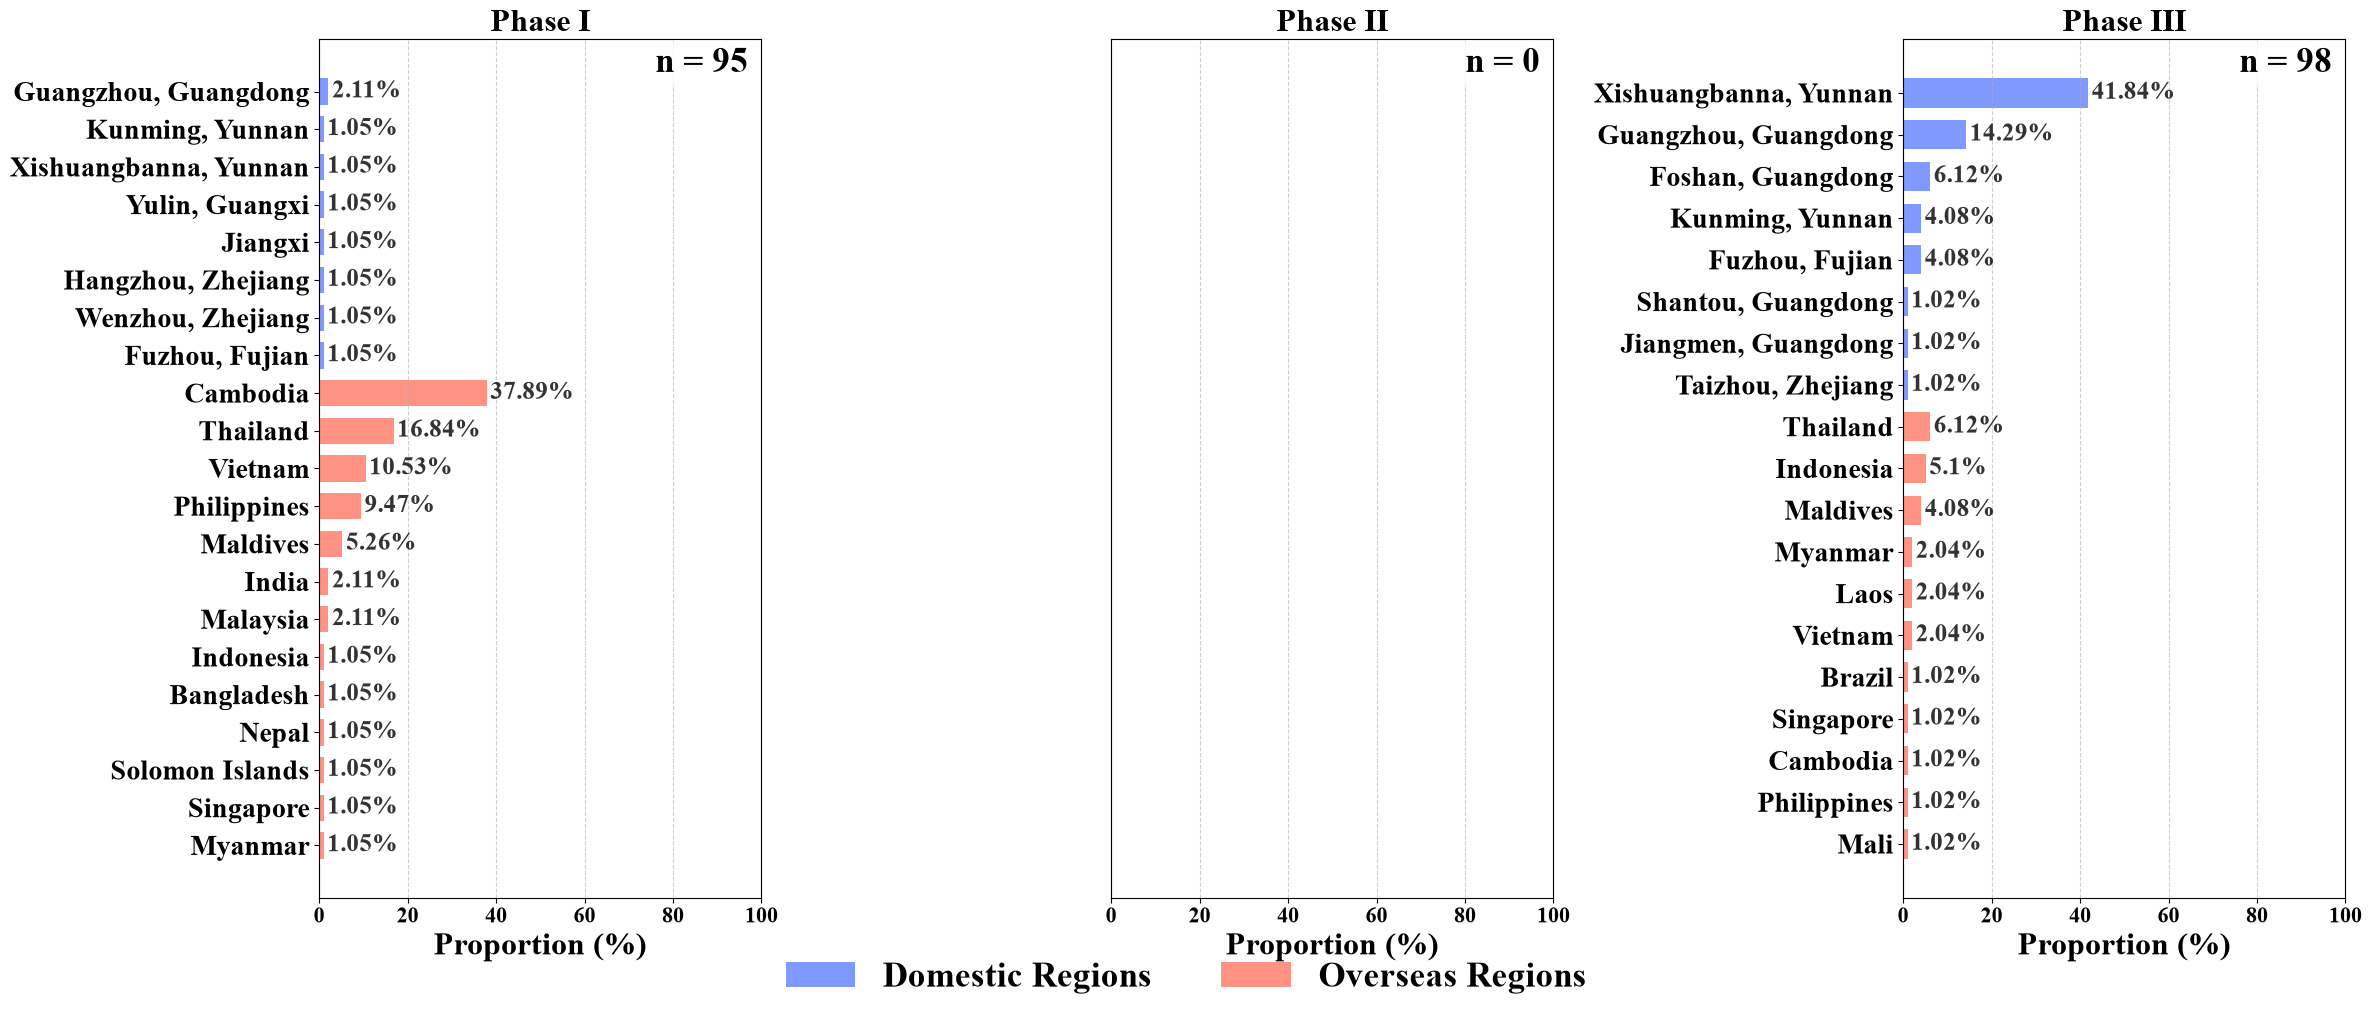

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib


# ====== 1. 加载数据 ======
# Fig4B

data = pd.read_excel('de-identified data.xlsx', index_col=0,sheet_name='Fig4B')  # 假设第一列是索引（阶段）



# ====== 2. 定义分类 ======
domestic_regions = [
    'Guangzhou, Guangdong',
    'Kunming, Yunnan',
    'Xishuangbanna, Yunnan',
    'Foshan, Guangdong',
    'Shantou, Guangdong',
    'Jiangmen, Guangdong',
    'Yulin, Guangxi',
    'Jiangxi',
    'Taizhou, Zhejiang',
    'Hangzhou, Zhejiang',
    'Wenzhou, Zhejiang',
    'Fuzhou, Fujian'
]

# ====== 3. 可视化函数 ======
def visualize_composition_matrix(data):
    # 初始化画布
    fig, axes = plt.subplots(1, 3, figsize=(24, 10))
    
    # 定义阶段标签
    phase_labels = ['Phase I', 'Phase II', 'Phase III']
    
    for phase_idx, ax in enumerate(axes):
        # 获取数据并计算比例
        phase_data = data.iloc[phase_idx]
        total = phase_data.sum()
        ratios = (phase_data / total * 100).round(2)
        
        # 分组排序
        domestic = ratios[ratios.index.isin(domestic_regions) & (ratios > 0)].sort_values(ascending=False)
        international = ratios[~ratios.index.isin(domestic_regions) & (ratios > 0)].sort_values(ascending=False)
        combined = pd.concat([domestic, international])
        
        # 生成颜色映射
        bar_colors = ['#8099FF' if idx in domestic_regions else '#FF9282' for idx in combined.index]
        
        # 绘制水平柱状图
        y_pos = np.arange(len(combined))
        bars = ax.barh(y_pos, combined, color=bar_colors, height=0.7)
        
        # 添加数据标签
        for bar, val in zip(bars, combined):
            ax.text(bar.get_width() + 0.8, 
                    bar.get_y() + bar.get_height()/2,
                    f'{val}%', 
                    va='center',
                    color='#333333',
                    fontsize=18)
        
        # 坐标轴设置
        ax.set_title(phase_labels[phase_idx], fontdict={'fontsize': 23, 'fontweight': 'bold'})
        ax.set_xlabel('Proportion (%)', fontdict={'fontsize': 23, 'fontweight': 'bold'})
        ax.set_xlim(0, 100)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(combined.index, fontsize=20)
        ax.invert_yaxis()
        ax.grid(axis='x', linestyle='--', alpha=0.6)
        
        # 添加样本量标注
        ax.text(0.97, 0.99, f'n = {total:.0f}', fontdict={'fontsize': 25, 'fontweight': 'bold'},
               transform=ax.transAxes,
               ha='right', va='top',
               bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    # 图例设置
    legend_elements = [
        plt.Rectangle((0, 0), 0.97, 0.97, fc='#8099FF', label='Domestic Regions'),
        plt.Rectangle((0, 0), 0.97, 0.97, fc='#FF9282', label='Overseas Regions')
    ]
    fig.legend(handles=legend_elements,
              loc='lower center',
              ncol=2,
              bbox_to_anchor=(0.5, -0.04),  # 调整图例垂直位置
              frameon=False,
              fontsize=25)
    
    # 调整布局
    plt.tight_layout()
    
   #plt.savefig('D:\\Research\\Project\\Dengue fever\\DF_nb\\输入病例输入国家分布.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig


# 运行可视化
fig = visualize_composition_matrix(data)

#### Fig 4C

In [37]:
def add_north(ax, labelsize=18, loc_x=0.88, loc_y=0.85, width=0.06, height=0.09, pad=0.14):
    """
    画一个比例尺带'N'文字注释
    主要参数如下
    :param ax: 要画的坐标区域 Axes实例 plt.gca()获取即可
    :param labelsize: 显示'N'文字的大小
    :param loc_x: 以文字下部为中心的占整个ax横向比例
    :param loc_y: 以文字下部为中心的占整个ax纵向比例
    :param width: 指南针占ax比例宽度
    :param height: 指南针占ax比例高度
    :param pad: 文字符号占ax比例间隙
    :return: None
    """
    minx, maxx = ax.get_xlim()
    miny, maxy = ax.get_ylim()
    ylen = maxy - miny
    xlen = maxx - minx
    left = [minx + xlen*(loc_x - width*.5), miny + ylen*(loc_y - pad)]
    right = [minx + xlen*(loc_x + width*.5), miny + ylen*(loc_y - pad)]
    top = [minx + xlen*loc_x, miny + ylen*(loc_y - pad + height)]
    center = [minx + xlen*loc_x, left[1] + (top[1] - left[1])*.4]
    triangle = mpatches.Polygon([left, top, right, center], color='k')
    ax.text(s='N',
            x=minx + xlen*loc_x,
            y=miny + ylen*(loc_y - pad + height),
            fontsize=labelsize,
            horizontalalignment='center',
            verticalalignment='bottom')
    ax.add_patch(triangle)

#-----------函数：添加比例尺--------------
def add_scalebar(ax,lon0,lat0,length,size=0.45):
    '''
    ax: 坐标轴
    lon0: 经度
    lat0: 纬度
    length: 长度
    size: 控制粗细和距离的
    '''
    # style 3
    ax.hlines(y=lat0,  xmin = lon0, xmax = lon0+length/111, colors="black", ls="-", lw=1, label='%d km' % (length))
    ax.vlines(x = lon0, ymin = lat0-size, ymax = lat0+size, colors="black", ls="-", lw=1)
    ax.vlines(x = lon0+length/2/111, ymin = lat0-size, ymax = lat0+size, colors="black", ls="-", lw=1)
    ax.vlines(x = lon0+length/111, ymin = lat0-size, ymax = lat0+size, colors="black", ls="-", lw=1)
    ax.text(lon0+length/111,lat0+size+0.05,'%d' % (length),horizontalalignment = 'center')
    ax.text(lon0+length/2/111,lat0+size+0.05,'%d' % (length/2),horizontalalignment = 'center')
    ax.text(lon0,lat0+size+0.05,'0',horizontalalignment = 'center')
    ax.text(lon0+length/111/2*3,lat0+size+0.05,'km',horizontalalignment = 'center')
    
    # style 1
    # print(help(ax.vlines))
    # ax.hlines(y=lat0,  xmin = lon0, xmax = lon0+length/111, colors="black", ls="-", lw=2, label='%d km' % (length))
    # ax.vlines(x = lon0, ymin = lat0-size, ymax = lat0+size, colors="black", ls="-", lw=2)
    # ax.vlines(x = lon0+length/111, ymin = lat0-size, ymax = lat0+size, colors="black", ls="-", lw=2)
    # # ax.text(lon0+length/2/111,lat0+size,'500 km',horizontalalignment = 'center')
    # ax.text(lon0+length/2/111,lat0+size,'%d' % (length/2),horizontalalignment = 'center')
    # ax.text(lon0,lat0+size,'0',horizontalalignment = 'center')
    # ax.text(lon0+length/111/2*3,lat0+size,'km',horizontalalignment = 'center')

    # style 2
    # plt.hlines(y=lat0,  xmin = lon0, xmax = lon0+length/111, colors="black", ls="-", lw=1, label='%d km' % (length))
    # plt.vlines(x = lon0, ymin = lat0-size, ymax = lat0+size, colors="black", ls="-", lw=1)
    # plt.vlines(x = lon0+length/111, ymin = lat0-size, ymax = lat0+size, colors="black", ls="-", lw=1)
    # plt.text(lon0+length/111,lat0+size,'%d km' % (length),horizontalalignment = 'center')
    # plt.text(lon0,lat0+size,'0',horizontalalignment = 'center')


使用地图数据中的 'NL_NAME_2' 列作为中文名称

地图数据中的区县名 (10个):
['海曙区' '江北区' '北仑区' '镇海区' '鄞州区' '奉化区' '象山县' '宁海县' '余姚市' '慈溪市']

Excel数据中的区县名 (10个):
['余姚市' '北仑区' '奉化区' '宁海县' '慈溪市' '江北区' '海曙区' '象山县' '鄞州区' '镇海区']


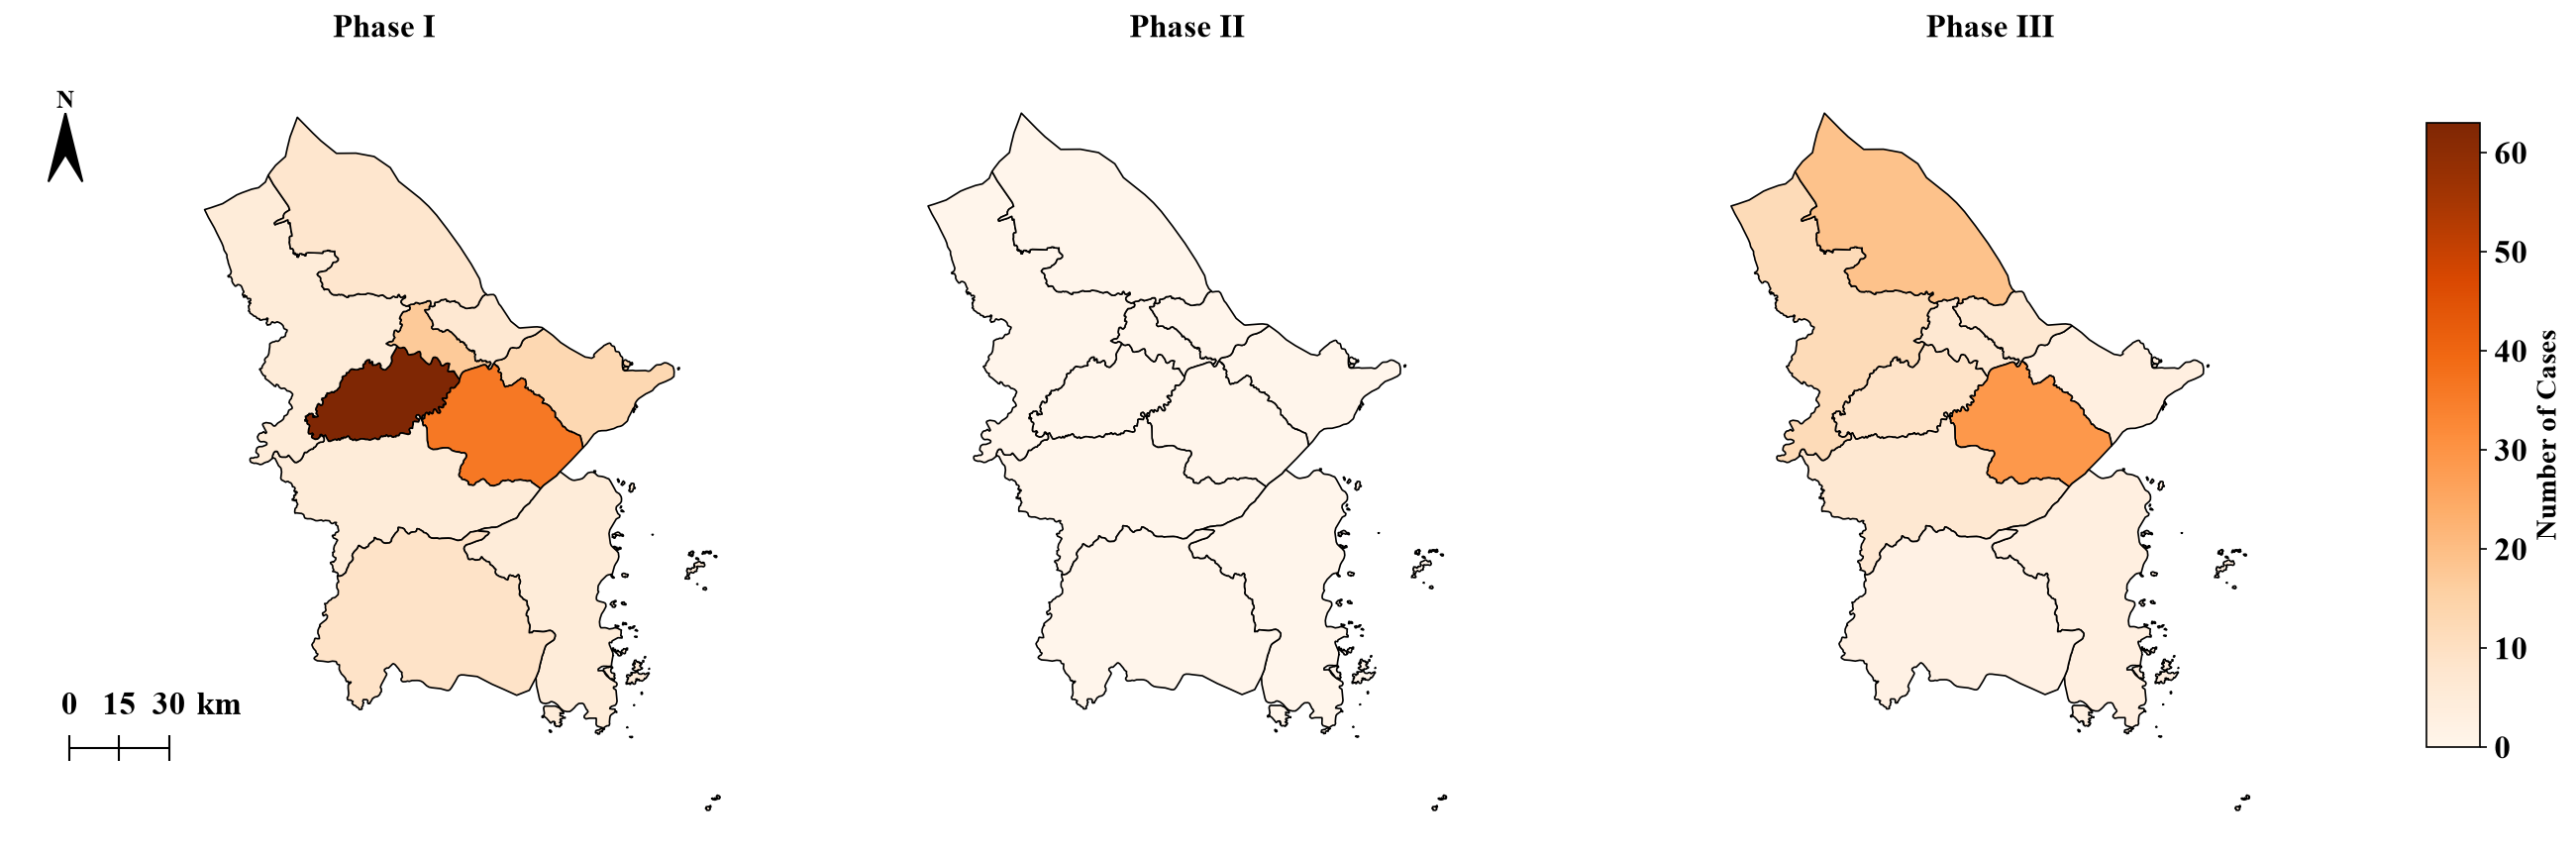

In [38]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import numpy as np
import os


gdf_gadm = gpd.read_file(r"gadm41_ningbo_2.json")
  


excel_data = pd.read_excel('de-identified data.xlsx', sheet_name='Fig4C')



# 检查地图数据中的中文名称列
map_name_column = None
possible_name_columns = ['NL_NAME_2', 'name', 'NL_NAME_2', 'NAME_2_CHN', 'district', '区县名']

for col in possible_name_columns:
    if col in gdf_gadm.columns:
        map_name_column = col
        print(f"使用地图数据中的 '{col}' 列作为中文名称")
        break

if map_name_column is None:
    print("警告: 未找到合适的中文名称列")
    print("地图数据列名:", gdf_gadm.columns.tolist())
    # 尝试使用第一列非几何列
    for col in gdf_gadm.columns:
        if col != 'geometry':
            map_name_column = col
            print(f"尝试使用 '{col}' 列")
            break

# 创建用于合并的列
gdf_gadm['合并名称'] = gdf_gadm[map_name_column]

# 检查名称匹配
print(f"\n地图数据中的区县名 ({len(gdf_gadm)}个):")
print(gdf_gadm['合并名称'].unique())

print(f"\nExcel数据中的区县名 ({len(excel_data)}个):")
# Excel中的区县名列名称可能是'district'，确认列名
excel_name_column = 'district' if 'district' in excel_data.columns else excel_data.columns[0]
excel_data = excel_data.rename(columns={excel_name_column: '合并名称'})
print(excel_data['合并名称'].unique())

# 查找不匹配的名称
missing_in_excel = set(gdf_gadm['合并名称']) - set(excel_data['合并名称'])
missing_in_map = set(excel_data['合并名称']) - set(gdf_gadm['合并名称'])

if len(missing_in_excel) > 0:
    print(f"\n警告: 以下地区在地图中有但Excel中无: {missing_in_excel}")
if len(missing_in_map) > 0:
    print(f"警告: 以下地区在Excel中有但地图中无: {missing_in_map}")


# 5. 准备阶段数据
phases = ['Phase I', 'Phase II', 'Phase III']
phase_colors = {
    'Phase I': '#fdae61',  # 浅橙色
    'Phase II': '#f46d43',  # 橙色
    'Phase III': '#d73027',  # 深橙色
}

# 确定颜色映射范围
max_cases = excel_data[phases].max().max()
min_cases = 0
norm = Normalize(vmin=min_cases, vmax=max_cases)

# 使用橙色系颜色映射
cmap = cm.Oranges

# 6. 创建1行3列的热力图
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)
axes = axes.flatten()

# 存储每个阶段的统计数据
phase_stats = []

# 绘制每个阶段的热力图
for idx, (ax, phase) in enumerate(zip(axes, phases)):
    # 合并地图数据和病例数据
    merged_data = gdf_gadm.merge(
        excel_data[['合并名称', phase]], 
        on='合并名称',
        how='left'
    )
    
    # 填充缺失值为0
    merged_data[phase] = merged_data[phase].fillna(0)
    
    # 绘制热力图
    merged_data.plot(ax=ax, column=phase, cmap=cmap, 
                    linewidth=0.8, edgecolor='black', 
                    norm=norm, legend=False)
    
    
    
    # 添加阶段标题
    ax.set_title(phase, fontsize=16, fontweight='bold', 
                fontfamily='Times New Roman', pad=20, 
                color='k')
    
    # 只在第一个子图添加指北针和比例尺
    if idx == 0:
        # 添加指北针
            add_north(ax, labelsize=12, loc_x=-0.2, loc_y=0.95, 
                    width=0.06, height=0.09, pad=0.08)
        
        # 添加比例尺（根据地图范围调整位置）
        # 使用宁波市中心经纬度附近的位置
            add_scalebar(ax, 120.5, 29.0, 30, size=0.03)
    
    # 关闭坐标轴
    ax.set_axis_off()
    
 
# 7. 添加颜色条
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Number of Cases', fontsize=14, 
               fontfamily='Times New Roman', fontweight='bold')


# 9. 调整布局
plt.tight_layout()
plt.subplots_adjust(right=0.9, wspace=0.05, top=0.9)


#plt.savefig('D:\\Research\\Project\\Dengue fever\\DF_nb\\病例分布热图.pdf', dpi=300, bbox_inches='tight')
# 显示图表
plt.show()






## 2. Epidemiological characteristics of Aedes albopictus monitoring

#### Figure 5

##### Fig 5A

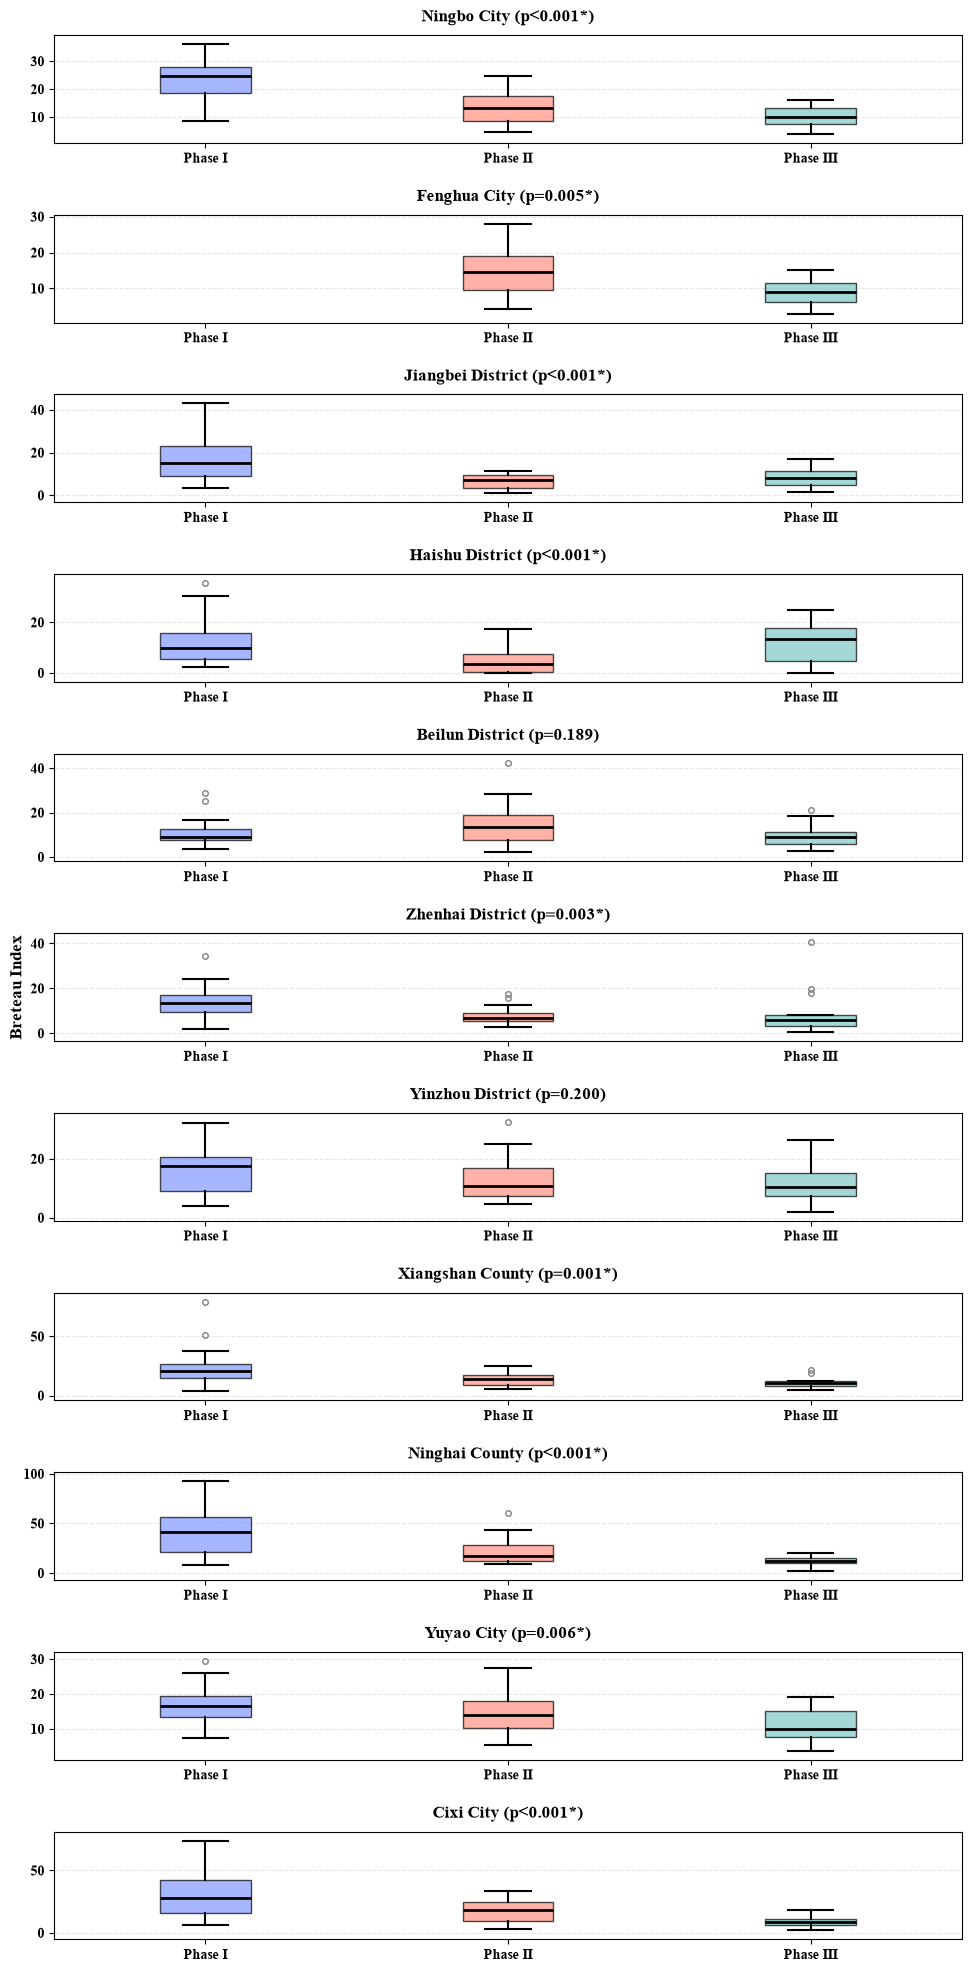

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import shapiro, levene, f_oneway, kruskal, ttest_ind, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# 1. 设置字体 - Times New Roman 粗体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.titleweight'] = 'bold'

# 2. 定义颜色
colors = ['#8099FF', '#FF9282', '#7CC8C5']
phase_labels = ['Phase I', 'Phase II', 'Phase III']

# 3. 定义地区名称映射
region_english_names = {
    '海曙区': 'Haishu District',
    '江北区': 'Jiangbei District',
    '北仑区': 'Beilun District',
    '镇海区': 'Zhenhai District',
    '鄞州区': 'Yinzhou District',
    '象山县': 'Xiangshan County',
    '宁海县': 'Ninghai County',
    '余姚市': 'Yuyao City',
    '慈溪市': 'Cixi City',
    '宁波市': 'Ningbo City',
    '奉化市': 'Fenghua City'
}

# 4. 加载数据
df = pd.read_excel('de-identified data.xlsx',sheet_name='Fig5A')

# 5. 优化统计检验函数 - 处理n=0的情况
def perform_statistical_test(phase1_data, phase2_data, phase3_data, alpha=0.05):
    """
    优化后的统计检验函数，处理n=0的情况
    返回p值和检验方法
    """
    # 过滤掉空数据和NaN
    phase1_valid = phase1_data[~np.isnan(phase1_data)] if len(phase1_data) > 0 else np.array([])
    phase2_valid = phase2_data[~np.isnan(phase2_data)] if len(phase2_data) > 0 else np.array([])
    phase3_valid = phase3_data[~np.isnan(phase3_data)] if len(phase3_data) > 0 else np.array([])
    
    # 计算有数据的阶段
    valid_data_dict = {
        'Phase I': phase1_valid,
        'Phase II': phase2_valid,
        'Phase III': phase3_valid
    }
    
    # 获取有数据的阶段列表
    valid_phases = [(label, data) for label, data in valid_data_dict.items() if len(data) > 0]
    
    # 如果少于2个阶段有数据，无法进行统计检验
    if len(valid_phases) < 2:
        return None, "Insufficient data (n<2)", []
    
    # 分离标签和数据
    valid_labels = [label for label, _ in valid_phases]
    valid_data = [data for _, data in valid_phases]
    
    # 如果只有2个阶段有数据，进行两独立样本检验
    if len(valid_data) == 2:
        data1, data2 = valid_data
        
        # 检查样本量是否足够
        if len(data1) < 2 or len(data2) < 2:
            return None, f"Insufficient sample size (n1={len(data1)}, n2={len(data2)})", valid_labels
        
        # 检查正态性
        if len(data1) >= 3 and len(data2) >= 3:
            # Shapiro检验需要至少3个样本
            _, p1 = shapiro(data1)
            _, p2 = shapiro(data2)
            normal = (p1 >= alpha) and (p2 >= alpha)
        else:
            # 样本量太小，使用非参数检验
            normal = False
        
        if normal:
            # 检查方差齐性
            _, p_var = levene(data1, data2)
            if p_var >= alpha:
                # 方差齐，使用独立样本t检验
                _, p_val = ttest_ind(data1, data2, equal_var=True)
                test_method = f"Two-sample t-test ({valid_labels[0]} vs {valid_labels[1]})"
            else:
                # 方差不齐，使用Welch's t检验
                _, p_val = ttest_ind(data1, data2, equal_var=False)
                test_method = f"Welch's t-test ({valid_labels[0]} vs {valid_labels[1]})"
        else:
            # 不满足正态性，使用Mann-Whitney U检验
            _, p_val = mannwhitneyu(data1, data2)
            test_method = f"Mann-Whitney U test ({valid_labels[0]} vs {valid_labels[1]})"
    
    # 如果3个阶段都有数据，进行三组比较
    else:
        data1, data2, data3 = valid_data
        
        # 检查每组数据是否满足正态性假设
        normal_tests = []
        for i, data in enumerate([data1, data2, data3], 1):
            if len(data) >= 3:  # Shapiro检验需要至少3个样本
                _, p_normal = shapiro(data)
                normal_tests.append(p_normal >= alpha)
            else:
                normal_tests.append(True)  # 样本太少，默认满足
        
        all_normal = all(normal_tests)
        
        if all_normal and len(data1) >= 2 and len(data2) >= 2 and len(data3) >= 2:
            # 检查方差齐性
            _, p_var = levene(data1, data2, data3)
            
            if p_var >= alpha:  # 方差齐
                # 使用单因素方差分析
                _, p_val = f_oneway(data1, data2, data3)
                test_method = "One-way ANOVA"
            else:  # 方差不齐
                # 使用Kruskal-Wallis检验
                _, p_val = kruskal(data1, data2, data3)
                test_method = "Kruskal-Wallis test"
        else:
            # 不满足正态性，使用非参数检验
            _, p_val = kruskal(data1, data2, data3)
            test_method = "Kruskal-Wallis test"
    
    return p_val, test_method, valid_labels

# 6. 创建子图
fig, axes = plt.subplots(11, 1, figsize=(10, 20))

# 7. 选择要绘制的地区
selected_regions = ['宁波市', '奉化市', '江北区', '海曙区', '北仑区', '镇海区',
                   '鄞州区', '象山县', '宁海县', '余姚市', '慈溪市']

# 8. 绘制每个地区的箱线图
for idx, (ax, region) in enumerate(zip(axes, selected_regions)):
    # 准备数据
    region_data = df[df['Region_Chinese'] == region]
    
    # 获取每个阶段的数据
    phase1_data = region_data[region_data['Phase'] == 1]['BI'].values
    phase2_data = region_data[region_data['Phase'] == 2]['BI'].values
    phase3_data = region_data[region_data['Phase'] == 3]['BI'].values
    
    # 确保每个阶段都有一个数据数组，即使为空
    data_for_plot = [phase1_data, phase2_data, phase3_data]
    
    # 进行统计检验
    p_val, test_method, valid_phases = perform_statistical_test(phase1_data, phase2_data, phase3_data)
    
    # 准备标题
    region_name = region_english_names[region]
    
    # 获取样本量
    sample_sizes = [len(phase1_data), len(phase2_data), len(phase3_data)]
    
    # 格式化标题文本
    if p_val is not None:
        if p_val < 0.001:
            p_text = "p<0.001*"
        elif p_val < 0.01:
            p_text = f"p={p_val:.3f}*"
        elif p_val < 0.05:
            p_text = f"p={p_val:.3f}*"
        else:
            p_text = f"p={p_val:.3f}"
        
        # 如果有有效数据，显示使用的检验方法
        if len(valid_phases) > 0:
            # 简化检验方法显示
            if "Two-sample" in test_method or "Welch" in test_method or "Mann-Whitney" in test_method:
                # 对于两样本检验，显示比较的阶段
                test_abbr = test_method.split('(')[0].strip()
            else:
                test_abbr = test_method
            
            title = f"{region_name} ({p_text})"
        else:
            title = f"{region_name} ({p_text})"
    else:
        title = f"{region_name} (No statistical test)"
    
    # 设置标题
    ax.set_title(title, fontsize=12, pad=10, fontweight='bold', fontfamily='Times New Roman')
    
    # 绘制箱线图 - 即使数据为空也绘制
    boxes = ax.boxplot(
        data_for_plot, 
        tick_labels=phase_labels, 
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.5, color='black'),
        capprops=dict(linewidth=1.5, color='black'),
        flierprops=dict(marker='o', markersize=4, markeredgecolor='gray')
    )
    
    # 设置箱体颜色
    for patch, color in zip(boxes['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # 设置y轴范围
    all_data = np.concatenate([d for d in data_for_plot if len(d) > 0])
    if len(all_data) > 0:
        y_min, y_max = np.min(all_data), np.max(all_data)
        y_range = y_max - y_min
        if y_range > 0:
            ax.set_ylim(y_min - 0.1*y_range, y_max + 0.1*y_range)
        else:
            # 如果所有值都相同
            ax.set_ylim(y_min - 1, y_max + 1)
    else:
        # 如果没有数据，设置默认范围
        ax.set_ylim(0, 10)
    
    # 设置y轴标签
    if idx == 5:  # 中间子图显示y轴标签
        ax.set_ylabel('Breteau Index', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
    
    # 显示网格线
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # 设置刻度标签字体
    ax.tick_params(axis='both', labelsize=10)
    for label in ax.get_xticklabels():
        label.set_fontfamily('Times New Roman')
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontfamily('Times New Roman')
        label.set_fontweight('bold')
    
    
# 9. 调整布局
plt.tight_layout()


plt.show()



##### Fig 5B

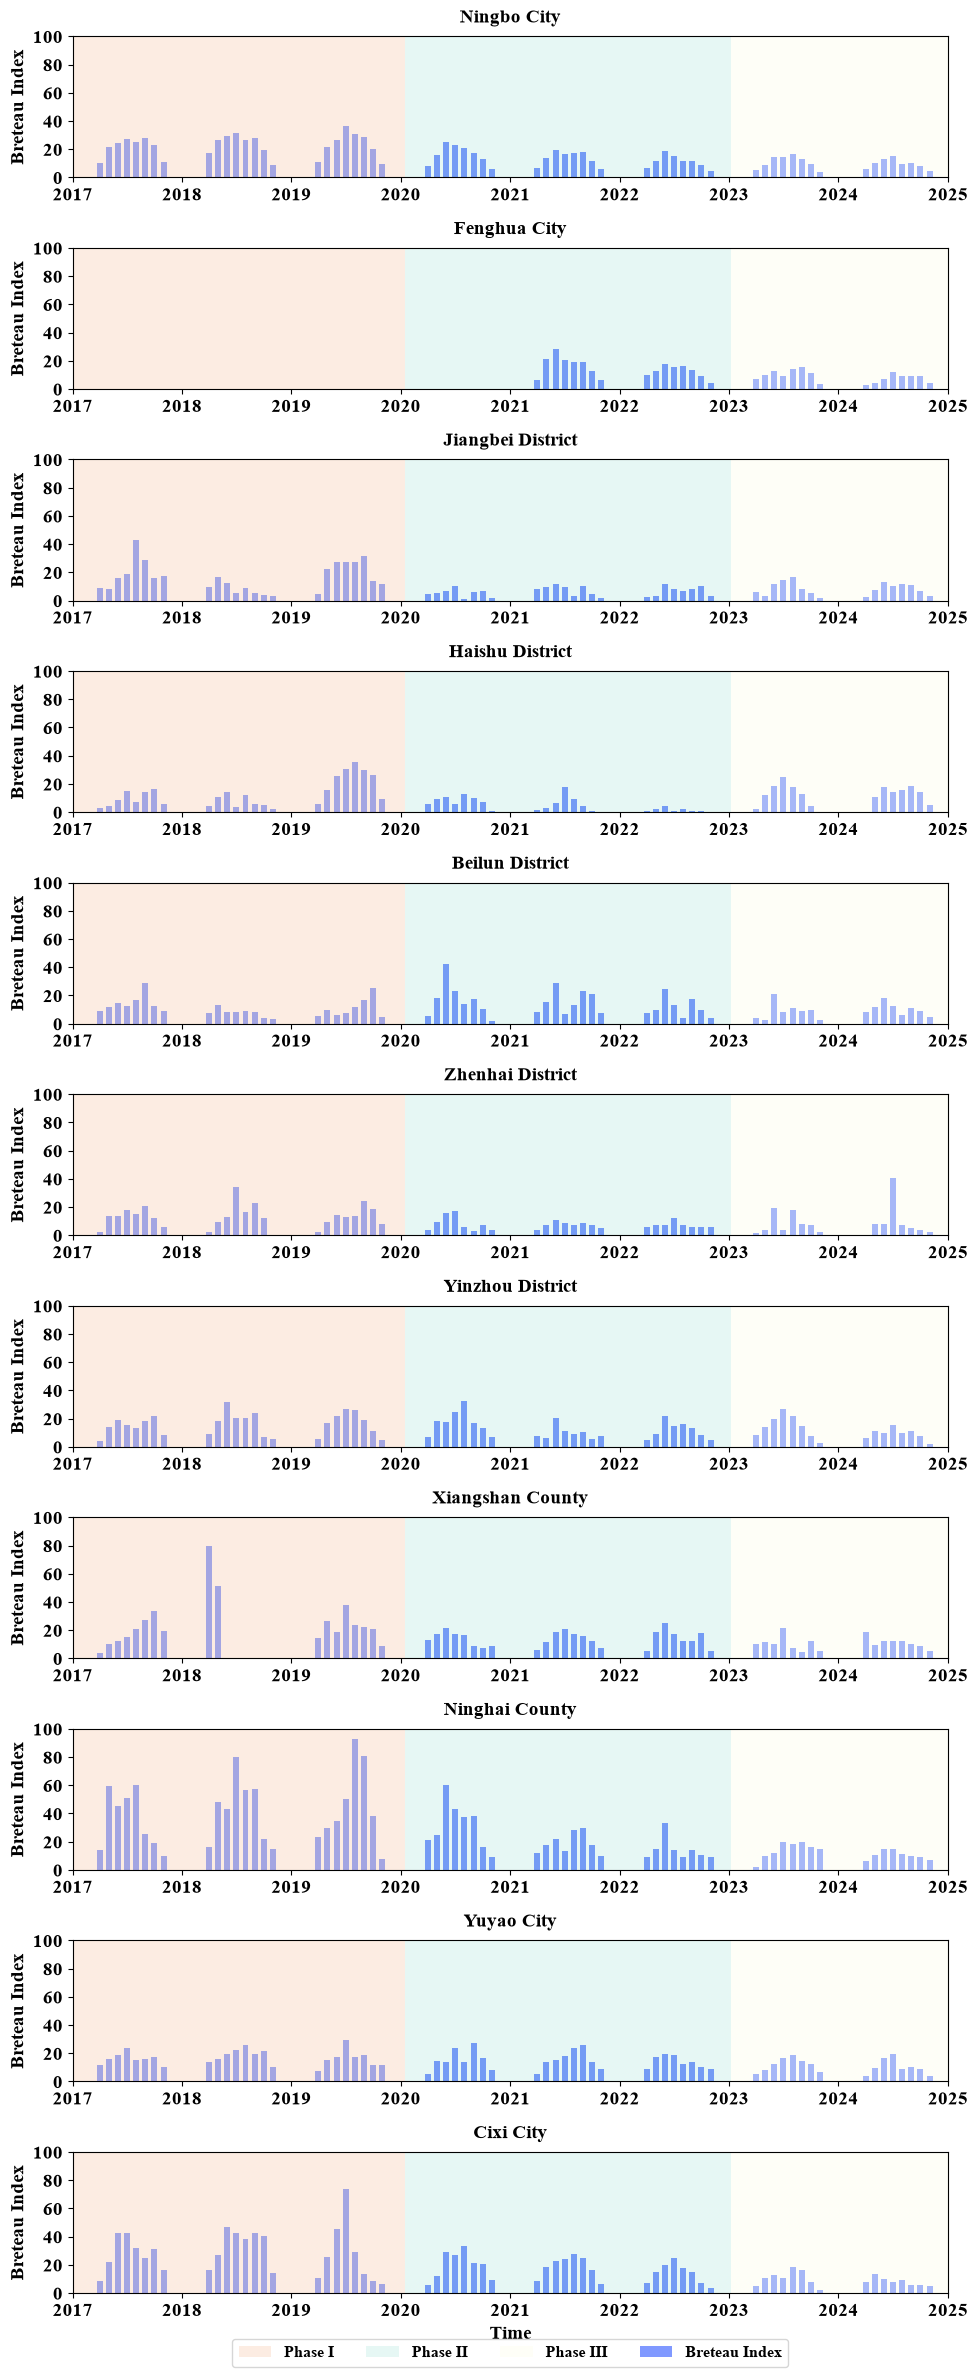

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置字体和样式
plt.rc('font', family='Times New Roman')
plt.rcParams.update({'font.size': 14})
plt.rcParams['font.weight'] = 'bold'

# 读取Excel文件
df = pd.read_excel('de-identified data.xlsx',sheet_name='Fig5B', index_col=0)  # 第一列作为索引
df.index = pd.to_datetime(df.index)  # 确保索引是datetime类型

# 地区信息
regions = ['宁波市', '奉化市', '江北区', '海曙区', '北仑区', '镇海区',
           '鄞州区', '象山县', '宁海县', '余姚市', '慈溪市']
region_names = {
    '宁波市': 'Ningbo City', '奉化市': 'Fenghua City',
    '江北区': 'Jiangbei District', '海曙区': 'Haishu District',
    '北仑区': 'Beilun District', '镇海区': 'Zhenhai District',
    '鄞州区': 'Yinzhou District', '象山县': 'Xiangshan County',
    '宁海县': 'Ninghai County', '余姚市': 'Yuyao City',
    '慈溪市': 'Cixi City'
}

# 阶段时间
phase1_end = np.datetime64('2020-01-14')
phase2_end = np.datetime64('2023-01-08')
xlim_start = np.datetime64('2017-01-01')
xlim_end = np.datetime64('2025-01-01')

# 创建子图
fig, axes = plt.subplots(11, 1, figsize=(10, 24))

# 绘制每个地区
for i, (ax, region) in enumerate(zip(axes, regions)):
    # 获取该地区数据
    region_data = df[df['地区'] == region]['BI']
    
    # 绘制柱状图
    ax.bar(region_data.index, region_data, color='#8099FF', width=20)
    
    # 设置标题和标签
    ax.set_title(region_names[region], fontsize=14, pad=10, fontweight='bold')
    ax.set_ylabel("Breteau Index", fontdict={'fontsize': 14, 'fontweight': 'bold'})
    ax.set_xlim(xlim_start, xlim_end)
    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 20))
    
    # 添加阶段背景
    ax.axvspan(xlim_start, phase1_end, facecolor='#F7C2A0', alpha=0.3)
    ax.axvspan(phase1_end, phase2_end, facecolor='#0DB194', alpha=0.1)
    ax.axvspan(phase2_end, xlim_end, facecolor='#FEFEE6', alpha=0.3)
    
    # 只在最后一张图显示x轴标签
    if i == 10:
        ax.set_xlabel("Time", fontdict={'fontsize': 14, 'fontweight': 'bold'})
        ax.legend(['Phase I', 'Phase II', 'Phase III', 'Breteau Index'], 
                 loc='upper center', bbox_to_anchor=(0.5, -0.27), ncol=4, fontsize='small')

# 调整布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)

plt.show()



## 3. Mathematical model analysis

### Figure 6

#### Fig 6A

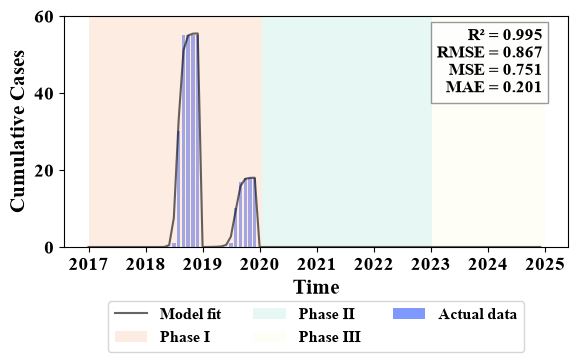

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 加载数据
fit = pd.read_excel('de-identified data.xlsx', sheet_name='Fig6A')
fit['Time'] = pd.to_datetime(fit['Time'])

# 计算统计指标
r2 = r2_score(fit['actual'], fit['Best_Fit'])
rmse = np.sqrt(mean_squared_error(fit['actual'], fit['Best_Fit']))
mse = mean_squared_error(fit['actual'], fit['Best_Fit'])
mae = mean_absolute_error(fit['actual'], fit['Best_Fit'])

# 创建图表
plt.figure(figsize=(6, 4))
plt.bar(fit['Time'], fit['actual'], color='#8099FF', label='Actual data', width=22)
plt.plot(fit['Time'], fit['Best_Fit'], 'k-', alpha=0.6, label='Model fit', linewidth=1.5)

# 添加阶段色块
plt.axvspan('2017-01-01', '2020-01-14', facecolor='#F7C2A0', alpha=0.3, label='Phase I')
plt.axvspan('2020-01-14', '2023-01-08', facecolor='#0DB194', alpha=0.1, label='Phase II')
plt.axvspan('2023-01-08', '2025-01-01', facecolor='#FEFEE6', alpha=0.3, label='Phase III')

# 添加统计文本
stats_text = f"R² = {r2:.3f}\nRMSE = {rmse:.3f}\nMSE = {mse:.3f}\nMAE = {mae:.3f}"
plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# 设置图表格式
#plt.xlim('2017-01-01', '2025-01-01')
plt.ylim(0, 60)
plt.xlabel('Time', fontsize=15, fontweight='bold')
plt.ylabel('Cumulative Cases', fontsize=15, fontweight='bold')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize='small')

# 显示图表
plt.tight_layout()

plt.show()

#### Fig 6B

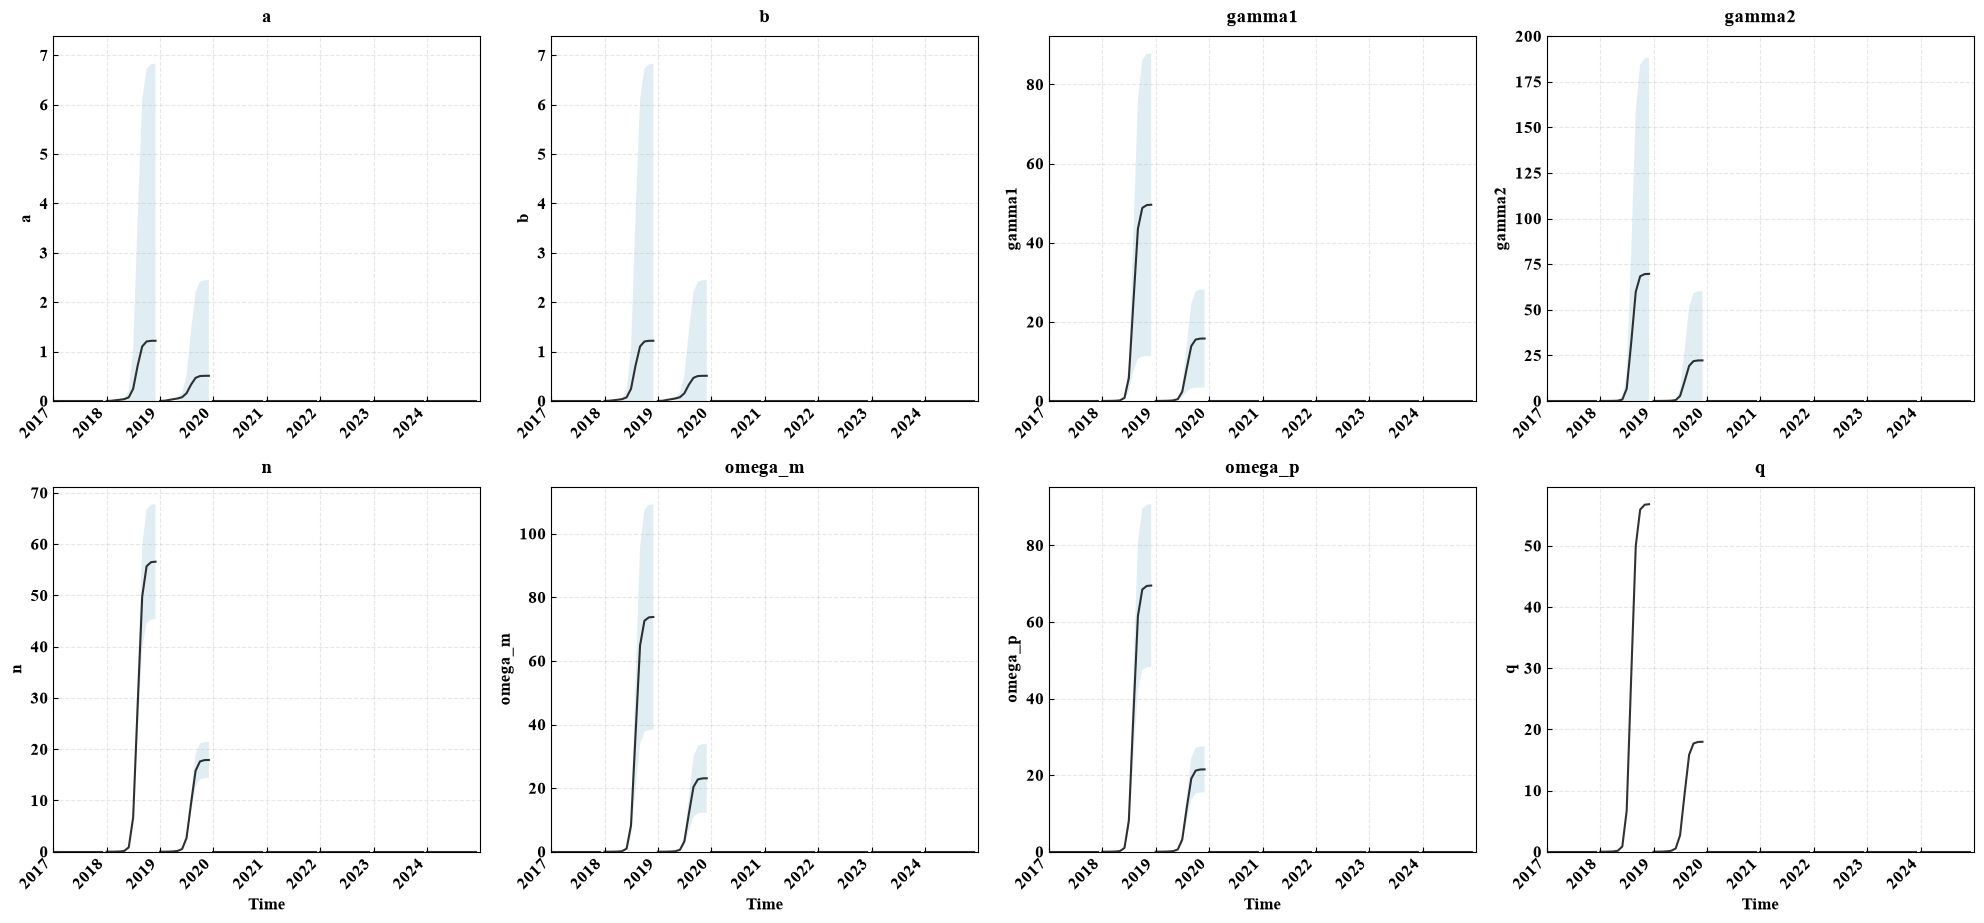

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# 设置全局字体和样式
plt.rc('font', family='Times New Roman')
plt.rcParams.update({'font.size': 12})
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

# 设置科学计数法的显示格式
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
class OOMFormatter(ScalarFormatter):
    def __init__(self, order=0, fformat="%1.1f", offset=True, mathText=True):
        self.order = order
        self.fformat = fformat
        ScalarFormatter.__init__(self, useOffset=offset, useMathText=mathText)
    
    def _set_order_of_magnitude(self):
        self.orderOfMagnitude = self.order
    
    def _set_format(self, vmin=None, vmax=None):
        self.format = self.fformat
        if self._useMathText:
            self.format = r'$\mathdefault{%s}$' % self.format


df = pd.read_excel('de-identified data.xlsx', sheet_name='Fig6B')

# 获取唯一的变量列表
variables = sorted(df['Variable'].unique())

# 确保有足够的数据
if len(variables) == 0:
    print("错误: 数据中没有找到任何变量")
    exit()

# 获取数据的起止年份
start_year = int(df['Year'].min())
end_year = int(df['Year'].max())

# 创建完整的日期范围（每月）
start_date = pd.to_datetime(f'{start_year}-01-01')
end_date = pd.to_datetime(f'{end_year}-12-31')
dates = pd.date_range(start=start_date, end=end_date, freq='M')

# 创建子图布局
n_vars = len(variables)
n_rows = 2
n_cols = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes = axes.flatten()  # 将2D轴数组展平为1D

# 存储每个变量的y轴范围，用于后续统一比例
y_limits = []

# 为每个变量创建子图
for idx, var in enumerate(variables):
    if idx >= len(axes):  # 防止索引超出范围
        break
        
    ax = axes[idx]
    
    # 筛选当前变量的数据
    var_data = df[df['Variable'] == var]
    
    # 确保有数据
    if var_data.empty:
        print(f"警告: 变量 {var} 没有数据")
        ax.text(0.5, 0.5, f'No data for {var}', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_title(var, fontsize=14, fontweight='bold', pad=10)
        continue
    
    # 按年和月分组计算统计量
    grouped = var_data.groupby(['Year', 'month'])['fit']
    mean_fit = grouped.mean()
    std_fit = grouped.std()
    U = mean_fit + std_fit
    L = mean_fit - std_fit
    
    # 为每年绘制线图和填充区域
    years_in_var = var_data['Year'].unique()
    
    for year in years_in_var:
        # 创建年份的日期范围
        year_dates = dates[dates.year == year]
        
        # 检查该年是否有数据
        if (year, 1) in mean_fit.index:  # 检查1月是否有数据
            # 收集该年12个月的数据
            year_mean = []
            year_U = []
            year_L = []
            valid_dates = []
            
            for month in range(1, 13):
                if (year, month) in mean_fit.index:
                    year_mean.append(mean_fit[(year, month)])
                    year_U.append(U[(year, month)])
                    year_L.append(L[(year, month)])
                    # 使用该月的第一天作为日期
                    valid_dates.append(pd.Timestamp(year=year, month=month, day=1))
            
            if len(year_mean) > 0:  # 如果有数据
                # 绘制均值线
                ax.plot(valid_dates, year_mean, color='k', linewidth=1.5, alpha=0.8)
                
                # 填充标准差区域
                ax.fill_between(valid_dates, year_L, year_U, 
                                alpha=0.3, facecolor='#9AC9DB')
    
    # 设置y轴从0开始
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(bottom=0)
    
    # 存储y轴范围
    y_limits.append((0, y_max))
    
    # 设置标题
    ax.set_title(var, fontsize=14, fontweight='bold', pad=10)
    
    # 设置x轴格式
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # 设置x轴范围
    ax.set_xlim([start_date, end_date])
    
    # 设置y轴标签
    ax.set_ylabel(var, fontsize=12, fontweight='bold')
    
    # 添加网格
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 设置刻度方向
    ax.tick_params(direction='in')
    
    # 如果变量值较大，使用科学计数法
    if y_max > 10000:
        ax.yaxis.set_major_formatter(OOMFormatter(4, "%1.1e"))
    elif y_max > 1000:
        ax.yaxis.set_major_formatter(OOMFormatter(3, "%1.1f"))
    
    # 自动调整x轴刻度以避免重叠
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 如果变量少于8个，隐藏多余的子图
for idx in range(len(variables), len(axes)):
    axes[idx].set_visible(False)

# 为最下面一行的子图添加x轴标签
for idx in range(n_vars):
    if idx >= n_cols:  # 第二行及以下
        axes[idx].set_xlabel('Time', fontsize=12, fontweight='bold')
    else:
        # 移除x轴标签
        axes[idx].set_xlabel('')

# 调整子图布局
plt.tight_layout(rect=[0, 0.03, 1, 0.97])



# 显示图形
plt.show()



#### Fig 6C

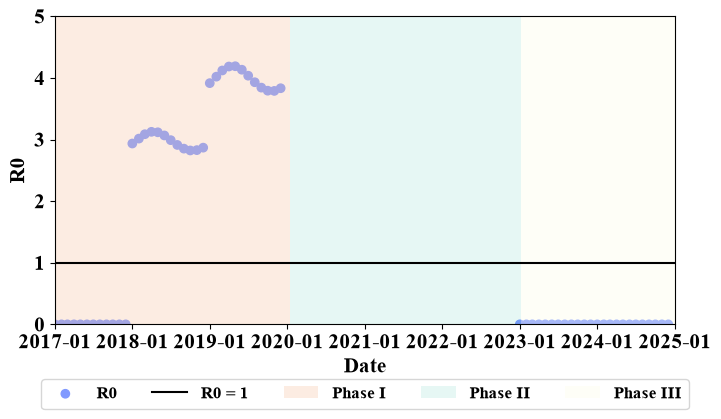

In [43]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df = pd.read_excel('de-identified data.xlsx', sheet_name='Fig6C')

plt.rc('font', family='Times New Roman')
plt.rcParams.update({'font.size': 15})
plt.rcParams['font.weight'] = 'bold'

plt.figure(figsize=(8,4))

# 绘制散点图
plt.scatter(df['Date'], df['R0'], 
           c=np.where(df['R0']>1, '#8099FF', '#8099FF'),  # 区分有效/填充数据
           #alpha=0.7,
           label='R0')

# 添加基准线
plt.axhline(y=1, color='black', linestyle='-', linewidth=1.5, label='R0 = 1')

# 日期格式优化
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m'))  # 精确到月份
#plt.gcf().autofmt_xdate()  # 自动旋转日期标签

plt.xlim(np.datetime64('2017-01-01'), np.datetime64('2025-01-01'))


plt.axvspan(np.datetime64('2017-01-01'), np.datetime64('2020-01-14'), facecolor='#F7C2A0', alpha=0.3, label='Phase I')
plt.axvspan(np.datetime64('2020-01-14'), np.datetime64('2023-01-08'), facecolor='#0DB194', alpha=0.1, label='Phase II')
plt.axvspan(np.datetime64('2023-01-08'), np.datetime64('2025-01-01'), facecolor='#FEFEE6', alpha=0.3, label='Phase III')



plt.xlabel('Date', fontsize=15,fontweight = 'bold')
plt.ylabel('R0', fontsize=15,fontweight = 'bold')
#plt.grid(alpha=0.3)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5,fontsize = 'small')
plt.ylim(0,5)

plt.show()

#### Fig 6D

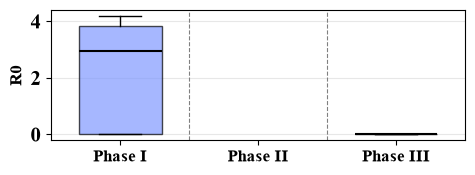

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取Excel数据
df_phases = pd.read_excel('de-identified data.xlsx',sheet_name='Fig6D')  

# 2. 定义阶段标签和颜色
rocket_palette = ['#8099FF', '#FF9282', '#7CC8C5']
phase_labels = ['Phase I', 'Phase II', 'Phase III']

# 3. 提取各阶段数据（去除NaN值）
phase_data = []
phase_samples = []  # 存储每个阶段的样本数
for i, label in enumerate(phase_labels):
    values = df_phases[label].dropna().values
    phase_data.append(values)
    phase_samples.append(f"{label}")

# 4. 创建图形
plt.figure(figsize=(5, 2))

# 5. 绘制箱线图
box = plt.boxplot(
    phase_data,
    positions=np.arange(len(phase_labels)),
    widths=0.6,
    patch_artist=True,
    showfliers=True,
    flierprops=dict(marker='o', markersize=5),
    medianprops={'color': 'black', 'linewidth': 1.5}
)

# 6. 设置颜色
for patch, color in zip(box['boxes'], rocket_palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# 7. 设置X轴标签（包含样本数）
plt.xticks(
    np.arange(len(phase_labels)),
    phase_samples,  # 显示阶段标签和样本数
    fontsize=12
)

# 8. 设置Y轴标签
plt.ylabel('R0', fontsize=12, fontweight='bold')

# 9. 添加网格
plt.grid(axis='y', alpha=0.3)

# 10. 添加阶段分割线
for i in range(1, len(phase_labels)):
    plt.axvline(x=i-0.5, color='gray', linestyle='--', linewidth=0.8)

# 11. 调整布局
plt.tight_layout()


plt.show()

